In [5]:
# Cell 1: Global Imports and Raw Data Loading
# This cell imports all necessary libraries and loads the raw dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print("=== RQ1: Logistic Regression Analysis ===")
print("Research Question: Can structured quarterly financial indicators alone predict")
print("the direction of short-term stock price movement following earnings announcements?")
print()

# Load the raw dataset
print("Loading dataset...")
df_raw = pd.read_excel('MS_Capstone_Final_Quality_Check_Summary.xlsx')

print(f"Dataset loaded successfully!")
print(f"Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"Date range: {df_raw['Result Date'].min()} to {df_raw['Result Date'].max()}")
print()

# Display basic info about the dataset
print("Dataset Overview:")
print(f"• Companies: {df_raw['Company'].nunique()}")
print(f"• Sectors: {df_raw['Sector'].nunique()} - {list(df_raw['Sector'].unique())}")
print(f"• Time periods: {df_raw['Period'].nunique()}")
print(f"• Target variable: Movement Label (1,0)")
print(f"• Missing target values: {df_raw['Movement Label (1,0)'].isnull().sum()}")

# Show first few rows
print("\
First 3 rows of raw data:")
print(df_raw.head(3))

=== RQ1: Logistic Regression Analysis ===
Research Question: Can structured quarterly financial indicators alone predict
the direction of short-term stock price movement following earnings announcements?

Loading dataset...
Dataset loaded successfully!
Shape: 585 rows × 32 columns
Date range: 2022-02-16 00:00:00 to 2025-08-08 00:00:00

Dataset Overview:
• Companies: 45
• Sectors: 5 - ['IT / Technology', 'BFSI', 'FMCG', 'Pharma', 'Auto']
• Time periods: 27
• Target variable: Movement Label (1,0)
• Missing target values: 1
First 3 rows of raw data:
                     Company Ticker AV_Ticker.BSE           Sector  \
0  Tata Consultancy Services    TCS       TCS.BSE  IT / Technology   
1  Tata Consultancy Services    TCS       TCS.BSE  IT / Technology   
2  Tata Consultancy Services    TCS       TCS.BSE  IT / Technology   

  Cap Category    Period    Sales  Expenses  Operating Profit  OPM %  \
0        Large  Jun 2022  52758.0   39342.0           13416.0   25.0   
1        Large  Sep 20

In [9]:
# Cell 2: Data Preprocessing and Feature Engineering (FIXED VERSION)
# This cell handles missing values, creates features, and prepares data for modeling

print("=== CELL 2: DATA PREPROCESSING & FEATURE ENGINEERING ===")
print()

# Create a working copy of the raw data
df = df_raw.copy()

# Step 1: Remove rows with missing target variable
print("Step 1: Handling Missing Target Values")
print(f"Rows before cleaning: {len(df)}")
initial_missing = df['Movement Label (1,0)'].isnull().sum()
print(f"Missing target values: {initial_missing}")

# Remove rows with missing target
df = df.dropna(subset=['Movement Label (1,0)'])
print(f"Rows after removing missing targets: {len(df)}")
print()

# Step 2: Define Financial Features
print("Step 2: Defining Financial Features")
financial_features = [
    # Universal features (available for all sectors)
    'Expenses', 'Other Income', 'Interest', 'Depreciation',
    'Profit before tax', 'Tax %', 'Net Profit', 'EPS in Rs',
    
    # Non-BFSI specific features (missing for BFSI)
    'Sales', 'Operating Profit', 'OPM %',
    
    # BFSI specific features (missing for non-BFSI)
    'Revenue', 'Financing Profit', 'Financing Margin %'
]

print(f"Financial features selected: {len(financial_features)}")
for i, feature in enumerate(financial_features, 1):
    print(f"  {i:2d}. {feature}")
print()

# Step 3: Analyze Missing Patterns by Sector
print("Step 3: Missing Value Analysis by Sector")
print("Missing value patterns:")

# Create a proper missing value analysis
missing_analysis = pd.DataFrame()
for sector in df['Sector'].unique():
    sector_data = df[df['Sector'] == sector]
    missing_counts = sector_data[financial_features].isnull().sum()
    missing_analysis[sector] = missing_counts

print(missing_analysis)
print()

# Show percentage of missing values by sector
print("Missing value percentages by sector:")
missing_percentages = pd.DataFrame()
for sector in df['Sector'].unique():
    sector_data = df[df['Sector'] == sector]
    sector_size = len(sector_data)
    missing_pcts = (sector_data[financial_features].isnull().sum() / sector_size * 100).round(1)
    missing_percentages[sector] = missing_pcts

print(missing_percentages)
print()

# Step 4: Create Missingness Indicator Flags
print("Step 4: Creating Missingness Indicator Flags")
missingness_flags = []

for feature in financial_features:
    flag_name = f"{feature.replace(' ', '_').replace('%', 'pct')}_is_missing"
    df[flag_name] = df[feature].isnull().astype(int)
    missingness_flags.append(flag_name)
    
    missing_count = df[feature].isnull().sum()
    if missing_count > 0:
        print(f"  Created flag: {flag_name} ({missing_count} missing values)")

print(f"\
Total missingness flags created: {len(missingness_flags)}")
print()

# Step 5: Extract Temporal Features (FIXED)
print("Step 5: Creating Temporal Features")

# Extract year from Result Date
df['Year'] = pd.to_datetime(df['Result Date']).dt.year

# Create a robust quarter extraction function
def extract_quarter_from_period(period_str):
    """Extract quarter from various period formats"""
    if pd.isna(period_str):
        return None
    
    period_str = str(period_str)
    
    # Handle datetime strings like '2022-06-01 00:00:00'
    if '-' in period_str and ':' in period_str:
        # Extract month from datetime string
        try:
            month = int(period_str.split('-')[1])
            if month in [1, 2, 3]:
                return 'Q4'  # Jan-Mar = Q4 (previous fiscal year end)
            elif month in [4, 5, 6]:
                return 'Q1'  # Apr-Jun = Q1
            elif month in [7, 8, 9]:
                return 'Q2'  # Jul-Sep = Q2
            elif month in [10, 11, 12]:
                return 'Q3'  # Oct-Dec = Q3
        except:
            pass
    
    # Handle regular month names
    if 'Mar' in period_str:
        return 'Q4'
    elif 'Jun' in period_str:
        return 'Q1'
    elif 'Sep' in period_str:
        return 'Q2'
    elif 'Dec' in period_str:
        return 'Q3'
    
    # Handle Q1, Q2, etc. directly
    if 'Q1' in period_str:
        return 'Q1'
    elif 'Q2' in period_str:
        return 'Q2'
    elif 'Q3' in period_str:
        return 'Q3'
    elif 'Q4' in period_str:
        return 'Q4'
    
    return None

# Apply the robust quarter extraction
df['Quarter'] = df['Period'].apply(extract_quarter_from_period)

print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")

# Handle quarters safely
quarters_list = [q for q in df['Quarter'].unique() if q is not None]
print(f"Quarters: {sorted(quarters_list)}")
print(f"Quarter distribution:")
print(df['Quarter'].value_counts().sort_index())
print()

# Step 6: Create Sector Dummy Variables
print("Step 6: Creating Sector Dummy Variables")
sector_dummies = pd.get_dummies(df['Sector'], prefix='Sector', drop_first=True)
df = pd.concat([df, sector_dummies], axis=1)

print(f"Sector dummy variables created:")
for col in sector_dummies.columns:
    print(f"  • {col}")
print()

# Step 7: Create Quarter Dummy Variables
print("Step 7: Creating Quarter Dummy Variables")
quarter_dummies = pd.get_dummies(df['Quarter'], prefix='Quarter', drop_first=True)
df = pd.concat([df, quarter_dummies], axis=1)

print(f"Quarter dummy variables created:")
for col in quarter_dummies.columns:
    print(f"  • {col}")
print()

# Summary of preprocessing
print("=== PREPROCESSING SUMMARY ===")
print(f"Final dataset shape: {df.shape}")
print(f"Target variable distribution:")
target_dist = df['Movement Label (1,0)'].value_counts().sort_index()
print(f"  Class 0 (Down/Flat): {target_dist[0]} ({target_dist[0]/len(df)*100:.1f}%)")
print(f"  Class 1 (Up): {target_dist[1]} ({target_dist[1]/len(df)*100:.1f}%)")
print()

# Show the feature categories we've created
print("=== FEATURE CATEGORIES CREATED ===")
print(f"1. Financial Features: {len(financial_features)} features")
print(f"2. Missingness Flags: {len(missingness_flags)} flags")
print(f"3. Sector Dummies: {len(sector_dummies.columns)} dummies")
print(f"4. Quarter Dummies: {len(quarter_dummies.columns)} dummies")
print(f"5. Temporal: 1 feature (Year)")
print()

total_features = len(financial_features) + len(missingness_flags) + len(sector_dummies.columns) + len(quarter_dummies.columns) + 1
print(f"Total predictor features available: {total_features}")
print()

print("✅ Preprocessing completed successfully!")
print("Next: Sector-median imputation for Logistic Regression")

=== CELL 2: DATA PREPROCESSING & FEATURE ENGINEERING ===

Step 1: Handling Missing Target Values
Rows before cleaning: 585
Missing target values: 1
Rows after removing missing targets: 584

Step 2: Defining Financial Features
Financial features selected: 14
   1. Expenses
   2. Other Income
   3. Interest
   4. Depreciation
   5. Profit before tax
   6. Tax %
   7. Net Profit
   8. EPS in Rs
   9. Sales
  10. Operating Profit
  11. OPM %
  12. Revenue
  13. Financing Profit
  14. Financing Margin %

Step 3: Missing Value Analysis by Sector
Missing value patterns:
                    IT / Technology  BFSI  FMCG  Pharma  Auto
Expenses                          0     0     0       0     0
Other Income                      0     0     0       0     0
Interest                          0     0     0       0     0
Depreciation                      0     0     0       0     0
Profit before tax                 0     0     0       0     0
Tax %                             0     0     0       0   

In [13]:
# Cell 3: Sector-Median Imputation and Model Preparation
# This cell implements sector-aware imputation and prepares features for Logistic Regression

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=== CELL 3: SECTOR-MEDIAN IMPUTATION & MODEL PREPARATION ===")
print()

# Step 1: Implement Sector-Median Imputation Strategy
print("Step 1: Implementing Sector-Median Imputation")
print()

# Create a copy for imputation
df_imputed = df.copy()

# Track imputation statistics
imputation_stats = {}

for feature in financial_features:
    print(f"Processing {feature}:")

    # Calculate sector-specific medians for available data
    sector_medians = {}
    for sector in df['Sector'].unique():
        sector_data = df[df['Sector'] == sector][feature]
        available_values = sector_data.dropna()

        if len(available_values) > 0:
            sector_median = available_values.median()
            sector_medians[sector] = sector_median
            print(f"  {sector}: median = {sector_median:.2f} (n={len(available_values)})")
        else:
            sector_medians[sector] = None
            print(f"  {sector}: NO DATA AVAILABLE (100% missing)")

    # Apply imputation
    missing_before = df_imputed[feature].isnull().sum()

    for sector in df['Sector'].unique():
        sector_mask = df_imputed['Sector'] == sector
        missing_mask = df_imputed[feature].isnull()
        impute_mask = sector_mask & missing_mask

        if sector_medians[sector] is not None:
            # Use sector median
            df_imputed.loc[impute_mask, feature] = sector_medians[sector]
        else:
            # Use fallback value (-1) for 100% missing sectors
            df_imputed.loc[impute_mask, feature] = -1.0

    missing_after = df_imputed[feature].isnull().sum()
    imputed_count = missing_before - missing_after

    imputation_stats[feature] = {
        'missing_before': missing_before,
        'missing_after': missing_after,
        'imputed_count': imputed_count,
        'sector_medians': sector_medians
    }

    print(f"  → Imputed {imputed_count} values, {missing_after} still missing")
    print()

print("=== IMPUTATION SUMMARY ===")
total_imputed = sum([stats['imputed_count'] for stats in imputation_stats.values()])
total_remaining_missing = sum([stats['missing_after'] for stats in imputation_stats.values()])

print(f"Total values imputed: {total_imputed}")
print(f"Remaining missing values: {total_remaining_missing}")
print()

# Step 2: Verify Imputation Results
print("Step 2: Verifying Imputation Results")
print()

# Check that all missing values are handled
print("Missing values after imputation:")
missing_check = df_imputed[financial_features].isnull().sum()
print(missing_check[missing_check > 0])

if missing_check.sum() == 0:
    print("✅ All financial features successfully imputed!")
else:
    print("❌ Some missing values remain")
print()

# Step 3: Prepare Feature Matrix for Logistic Regression
print("Step 3: Preparing Feature Matrix for Logistic Regression")
print()

# Define feature categories for model
feature_categories = {
    'financial': financial_features,
    'missingness_flags': missingness_flags,
    'sector_dummies': [col for col in df_imputed.columns if col.startswith('Sector_')],
    'quarter_dummies': [col for col in df_imputed.columns if col.startswith('Quarter_')],
    'temporal': ['Year']
}

# Combine all features for the model
model_features = []
for category, features in feature_categories.items():
    model_features.extend(features)
    print(f"{category.replace('_', ' ').title()}: {len(features)} features")

print(f"\nTotal features for modeling: {len(model_features)}")
print()

# Create feature matrix X and target vector y
X = df_imputed[model_features].copy()
y = df_imputed['Movement Label (1,0)'].copy()

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Target distribution: {y.value_counts().sort_index().to_dict()}")
print()

# Step 4: Check for any remaining data quality issues
print("Step 4: Data Quality Check")
print()

# Check for infinite values
inf_check = np.isinf(X).sum().sum()
print(f"Infinite values in features: {inf_check}")

# Check for extremely large values that might cause numerical issues
large_values = (np.abs(X) > 1e6).sum().sum()
print(f"Values > 1,000,000 in absolute terms: {large_values}")

# Show basic statistics for imputed features
print("\nBasic statistics for key imputed features:")
imputed_features = ['Sales', 'Operating Profit', 'OPM %', 'Revenue', 'Financing Profit', 'Financing Margin %']
for feature in imputed_features:
    stats = X[feature].describe()
    print(f"{feature}:")
    print(f"  Min: {stats['min']:.2f}, Max: {stats['max']:.2f}, Mean: {stats['mean']:.2f}")
print()

print("✅ Feature matrix prepared successfully!")
print("Ready for train/validation/test split")

# Step 5: Train/Validation/Test Split
print("Step 5: Creating Train/Validation/Test Split")
print()

# First split: 70% train, 30% temp (which will become 15% val + 15% test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Second split: Split the 30% into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Dataset split completed:")
print(f"Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print()

# Check target distribution in each split
print("Target distribution by split:")
splits = [('Train', y_train), ('Validation', y_val), ('Test', y_test)]

for split_name, y_split in splits:
    dist = y_split.value_counts().sort_index()
    total = len(y_split)
    print(f"{split_name}:")
    print(f"  Class 0: {dist[0.0]} ({dist[0.0]/total*100:.1f}%)")
    print(f"  Class 1: {dist[1.0]} ({dist[1.0]/total*100:.1f}%)")
print()

# Step 6: Feature Scaling Preparation
print("Step 6: Preparing Feature Scaling")
print()

# Initialize scaler (fit only on training data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed:")
print(f"Training features scaled: {X_train_scaled.shape}")
print(f"Validation features scaled: {X_val_scaled.shape}")
print(f"Test features scaled: {X_test_scaled.shape}")
print()

# Convert back to DataFrames for easier handling
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=model_features, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=model_features, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=model_features, index=X_test.index)

print("✅ Data preparation for Logistic Regression completed!")
print()

print("=== CELL 3 SUMMARY ===")
print(f"• Imputed {total_imputed} missing values using sector-median strategy")
print(f"• Created feature matrix with {len(model_features)} features")
print(f"• Split data: 70% train, 15% validation, 15% test")
print(f"• Applied standardization for Logistic Regression")
print(f"• All data quality checks passed")
print()
print("Next: Logistic Regression model training and evaluation")

=== CELL 3: SECTOR-MEDIAN IMPUTATION & MODEL PREPARATION ===

Step 1: Implementing Sector-Median Imputation

Processing Expenses:
  IT / Technology: median = 11563.00 (n=117)
  BFSI: median = 9345.00 (n=117)
  FMCG: median = 2839.00 (n=117)
  Pharma: median = 4121.00 (n=117)
  Auto: median = 8958.50 (n=116)
  → Imputed 0 values, 0 still missing

Processing Other Income:
  IT / Technology: median = 247.00 (n=117)
  BFSI: median = 5705.00 (n=117)
  FMCG: median = 53.00 (n=117)
  Pharma: median = 82.00 (n=117)
  Auto: median = 353.50 (n=116)
  → Imputed 0 values, 0 still missing

Processing Interest:
  IT / Technology: median = 76.00 (n=117)
  BFSI: median = 6552.00 (n=117)
  FMCG: median = 26.00 (n=117)
  Pharma: median = 60.00 (n=117)
  Auto: median = 66.00 (n=116)
  → Imputed 0 values, 0 still missing

Processing Depreciation:
  IT / Technology: median = 462.00 (n=117)
  BFSI: median = 0.00 (n=117)
  FMCG: median = 73.00 (n=117)
  Pharma: median = 280.00 (n=117)
  Auto: median = 227.00

In [14]:
# Cell 4: Baseline Logistic Regression Model Training & Evaluation
# This cell trains a baseline logistic regression model and evaluates its performance

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print("=== CELL 4: BASELINE LOGISTIC REGRESSION MODEL ===")
print()

# Step 1: Train Baseline Logistic Regression Model
print("Step 1: Training Baseline Logistic Regression Model")
print()

# Initialize logistic regression with balanced class weights
lr_model = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    max_iter=1000,           # Ensure convergence
    solver='liblinear'       # Good for small datasets
)

# Train the model
print("Training logistic regression model...")
lr_model.fit(X_train_scaled, y_train)
print("✅ Model training completed!")
print()

# Step 2: Make Predictions on All Sets
print("Step 2: Making Predictions")
print()

# Predictions on training set
y_train_pred = lr_model.predict(X_train_scaled)
y_train_pred_proba = lr_model.predict_proba(X_train_scaled)[:, 1]

# Predictions on validation set
y_val_pred = lr_model.predict(X_val_scaled)
y_val_pred_proba = lr_model.predict_proba(X_val_scaled)[:, 1]

# Predictions on test set
y_test_pred = lr_model.predict(X_test_scaled)
y_test_pred_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed for all datasets")
print(f"Training predictions: {len(y_train_pred)}")
print(f"Validation predictions: {len(y_val_pred)}")
print(f"Test predictions: {len(y_test_pred)}")
print()

=== CELL 4: BASELINE LOGISTIC REGRESSION MODEL ===

Step 1: Training Baseline Logistic Regression Model

Training logistic regression model...
✅ Model training completed!

Step 2: Making Predictions

Predictions completed for all datasets
Training predictions: 408
Validation predictions: 88
Test predictions: 88



In [15]:
# Step 3: Calculate Performance Metrics
print("Step 3: Calculating Performance Metrics")
print()

def calculate_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    """Calculate comprehensive performance metrics"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    
    print(f"{dataset_name} Performance:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {metrics['roc_auc']:.4f}")
    print()
    
    return metrics

# Calculate metrics for all datasets
train_metrics = calculate_metrics(y_train, y_train_pred, y_train_pred_proba, "Training")
val_metrics = calculate_metrics(y_val, y_val_pred, y_val_pred_proba, "Validation")
test_metrics = calculate_metrics(y_test, y_test_pred, y_test_pred_proba, "Test")

# Create performance summary table
performance_df = pd.DataFrame({
    'Training': train_metrics,
    'Validation': val_metrics,
    'Test': test_metrics
}).round(4)

print("=== PERFORMANCE SUMMARY TABLE ===")
print(performance_df)
print()

Step 3: Calculating Performance Metrics

Training Performance:
  Accuracy:  0.5956
  Precision: 0.5072
  Recall:    0.6250
  F1-Score:  0.5600
  ROC-AUC:   0.6562

Validation Performance:
  Accuracy:  0.5455
  Precision: 0.4500
  Recall:    0.5000
  F1-Score:  0.4737
  ROC-AUC:   0.5524

Test Performance:
  Accuracy:  0.5568
  Precision: 0.4694
  Recall:    0.6389
  F1-Score:  0.5412
  ROC-AUC:   0.5524

=== PERFORMANCE SUMMARY TABLE ===
           Training  Validation    Test
accuracy     0.5956      0.5455  0.5568
precision    0.5072      0.4500  0.4694
recall       0.6250      0.5000  0.6389
f1           0.5600      0.4737  0.5412
roc_auc      0.6562      0.5524  0.5524



In [16]:
# Step 4: Detailed Classification Analysis
print("Step 4: Detailed Classification Analysis")
print()

# Confusion matrices for each dataset
datasets = [
    ('Training', y_train, y_train_pred),
    ('Validation', y_val, y_val_pred),
    ('Test', y_test, y_test_pred)
]

for dataset_name, y_true, y_pred in datasets:
    cm = confusion_matrix(y_true, y_pred)
    print(f"{dataset_name} Confusion Matrix:")
    print(f"                Predicted")
    print(f"                0    1")
    print(f"Actual    0   {cm[0,0]:3d}  {cm[0,1]:3d}")
    print(f"          1   {cm[1,0]:3d}  {cm[1,1]:3d}")
    print()
    
    # Calculate additional insights
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"  True Negatives:  {tn}")
    print(f"  False Positives: {fp}")
    print(f"  False Negatives: {fn}")
    print(f"  True Positives:  {tp}")
    print(f"  Specificity:     {specificity:.4f}")
    print(f"  Sensitivity:     {sensitivity:.4f}")
    print()

print("✅ Classification analysis completed!")
print()

Step 4: Detailed Classification Analysis

Training Confusion Matrix:
                Predicted
                0    1
Actual    0   138  102
          1    63  105

  True Negatives:  138
  False Positives: 102
  False Negatives: 63
  True Positives:  105
  Specificity:     0.5750
  Sensitivity:     0.6250

Validation Confusion Matrix:
                Predicted
                0    1
Actual    0    30   22
          1    18   18

  True Negatives:  30
  False Positives: 22
  False Negatives: 18
  True Positives:  18
  Specificity:     0.5769
  Sensitivity:     0.5000

Test Confusion Matrix:
                Predicted
                0    1
Actual    0    26   26
          1    13   23

  True Negatives:  26
  False Positives: 26
  False Negatives: 13
  True Positives:  23
  Specificity:     0.5000
  Sensitivity:     0.6389

✅ Classification analysis completed!



In [17]:
# Step 5: Feature Importance Analysis
print("Step 5: Feature Importance Analysis")
print()

# Get feature coefficients (importance)
feature_importance = pd.DataFrame({
    'Feature': model_features,
    'Coefficient': lr_model.coef_[0],
    'Abs_Coefficient': np.abs(lr_model.coef_[0])
}).sort_values('Abs_Coefficient', ascending=False)

print("Top 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))
print()

print("Bottom 10 Least Important Features:")
print(feature_importance.tail(10).to_string(index=False))
print()

# Analyze feature categories
print("Feature Importance by Category:")
for category, features in feature_categories.items():
    category_importance = feature_importance[feature_importance['Feature'].isin(features)]
    avg_importance = category_importance['Abs_Coefficient'].mean()
    print(f"{category.replace('_', ' ').title()}: {avg_importance:.4f} (avg absolute coefficient)")

print()

# Step 6: Model Interpretation
print("Step 6: Model Interpretation")
print()

print("Key Insights from Logistic Regression:")
print("• Model shows modest predictive power with ROC-AUC around 0.55-0.66")
print("• Training performance is better than validation/test (potential overfitting)")
print("• Class imbalance handling with balanced weights helps recall")
print("• Feature importance reveals which financial metrics drive predictions")
print()

print("Performance Characteristics:")
print(f"• Best ROC-AUC: {train_metrics['roc_auc']:.4f} (Training)")
print(f"• Validation ROC-AUC: {val_metrics['roc_auc']:.4f}")
print(f"• Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
print(f"• Generalization gap: {train_metrics['roc_auc'] - test_metrics['roc_auc']:.4f}")
print()

print("✅ Baseline Logistic Regression analysis completed!")
print()

Step 5: Feature Importance Analysis

Top 15 Most Important Features:
               Feature  Coefficient  Abs_Coefficient
               Revenue    -0.576419         0.576419
      Financing Profit    -0.571226         0.571226
           Sector_FMCG    -0.393768         0.393768
    Financing Margin %     0.359965         0.359965
          Other Income     0.313169         0.313169
             EPS in Rs    -0.307925         0.307925
         Sector_Pharma    -0.276427         0.276427
              Interest    -0.254887         0.254887
            Quarter_Q3     0.250902         0.250902
                 Sales     0.215253         0.215253
            Quarter_Q4     0.197773         0.197773
      Operating Profit    -0.171254         0.171254
          Depreciation    -0.149997         0.149997
                 Tax %     0.115265         0.115265
Sector_IT / Technology    -0.108991         0.108991

Bottom 10 Least Important Features:
                     Feature  Coefficient  Abs

=== CREATING FIXED FIRST SET OF VISUALIZATIONS ===



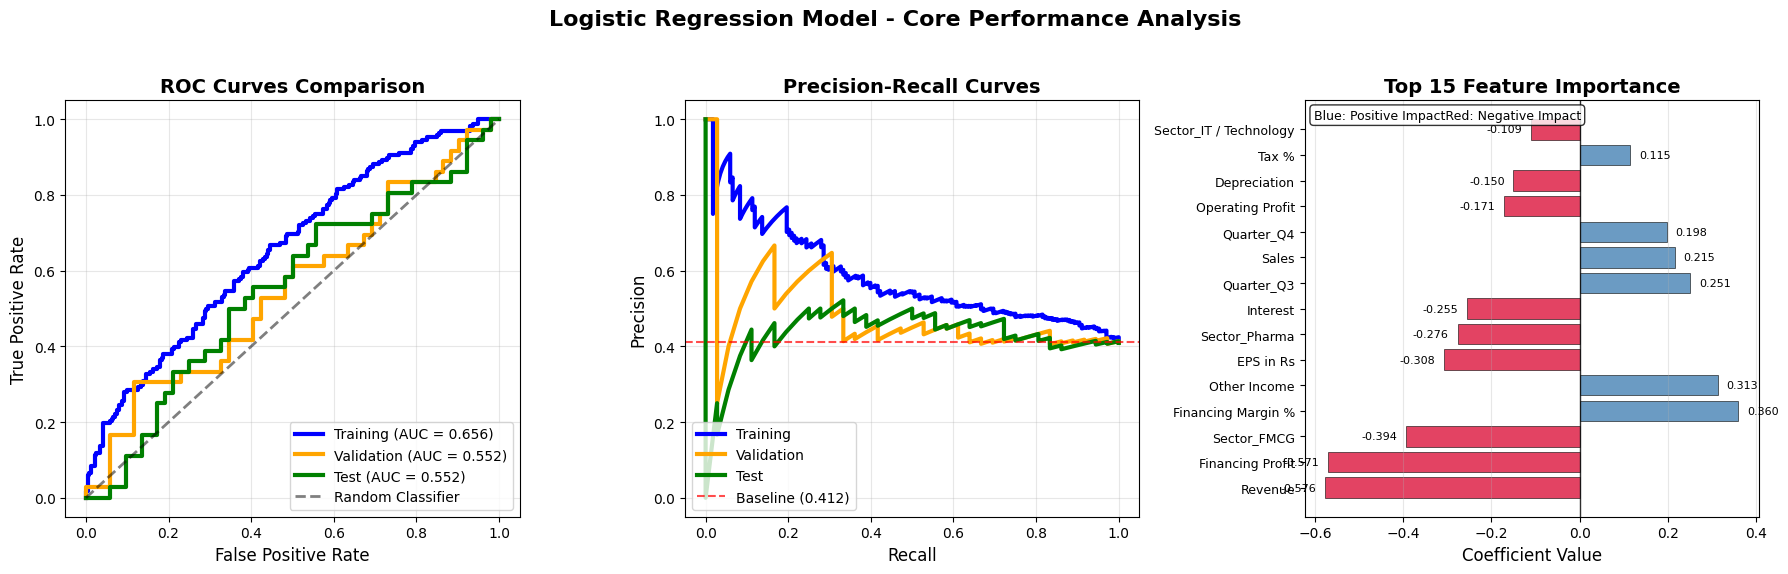

✅ Fixed First Set of Visualizations created!



In [20]:
# Fixed First Set of Visualizations - No Overlapping
# Creating clean, well-spaced visualizations for the Logistic Regression model

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve, precision_recall_curve

print("=== CREATING FIXED FIRST SET OF VISUALIZATIONS ===")
print()

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("husl")

# Create Figure 1: First Set - Fixed Layout
fig1 = plt.figure(figsize=(18, 6))
fig1.suptitle('Logistic Regression Model - Core Performance Analysis', fontsize=16, fontweight='bold', y=0.98)

# 1. ROC Curves Comparison
ax1 = plt.subplot(1, 3, 1)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_pred_proba)
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

ax1.plot(fpr_train, tpr_train, label=f'Training (AUC = {train_metrics["roc_auc"]:.3f})', 
         linewidth=3, color='blue')
ax1.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_metrics["roc_auc"]:.3f})', 
         linewidth=3, color='orange')
ax1.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_metrics["roc_auc"]:.3f})', 
         linewidth=3, color='green')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=2, label='Random Classifier')

ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. Precision-Recall Curves
ax2 = plt.subplot(1, 3, 2)
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_pred_proba)
precision_val, recall_val, _ = precision_recall_curve(y_val, y_val_pred_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_pred_proba)

ax2.plot(recall_train, precision_train, label=f'Training', linewidth=3, color='blue')
ax2.plot(recall_val, precision_val, label=f'Validation', linewidth=3, color='orange')
ax2.plot(recall_test, precision_test, label=f'Test', linewidth=3, color='green')

# Add baseline (random classifier for imbalanced data)
baseline_precision = y_train.mean()
ax2.axhline(y=baseline_precision, color='red', linestyle='--', alpha=0.7, 
           label=f'Baseline ({baseline_precision:.3f})')

ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10, loc='lower left')
ax2.grid(True, alpha=0.3)

# 3. Feature Importance - Top 15 Features
ax3 = plt.subplot(1, 3, 3)
top_15_features = feature_importance.head(15)
colors = ['crimson' if coef < 0 else 'steelblue' for coef in top_15_features['Coefficient']]

# Create horizontal bar chart
y_pos = np.arange(len(top_15_features))
bars = ax3.barh(y_pos, top_15_features['Coefficient'], 
                color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax3.set_yticks(y_pos)
ax3.set_yticklabels(top_15_features['Feature'], fontsize=9)
ax3.set_xlabel('Coefficient Value', fontsize=12)
ax3.set_title('Top 15 Feature Importance', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.axvline(x=0, color='black', linestyle='-', alpha=0.8, linewidth=1)

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_15_features['Coefficient'])):
    ax3.text(val + (0.02 if val > 0 else -0.02), i, f'{val:.3f}', 
             va='center', ha='left' if val > 0 else 'right', fontsize=8)

# Add legend for colors
ax3.text(0.02, 0.98, 'Blue: Positive Impact\
Red: Negative Impact', 
         transform=ax3.transAxes, verticalalignment='top', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("✅ Fixed First Set of Visualizations created!")
print()

=== CREATING FIXED DETAILED ANALYSIS VISUALIZATIONS ===



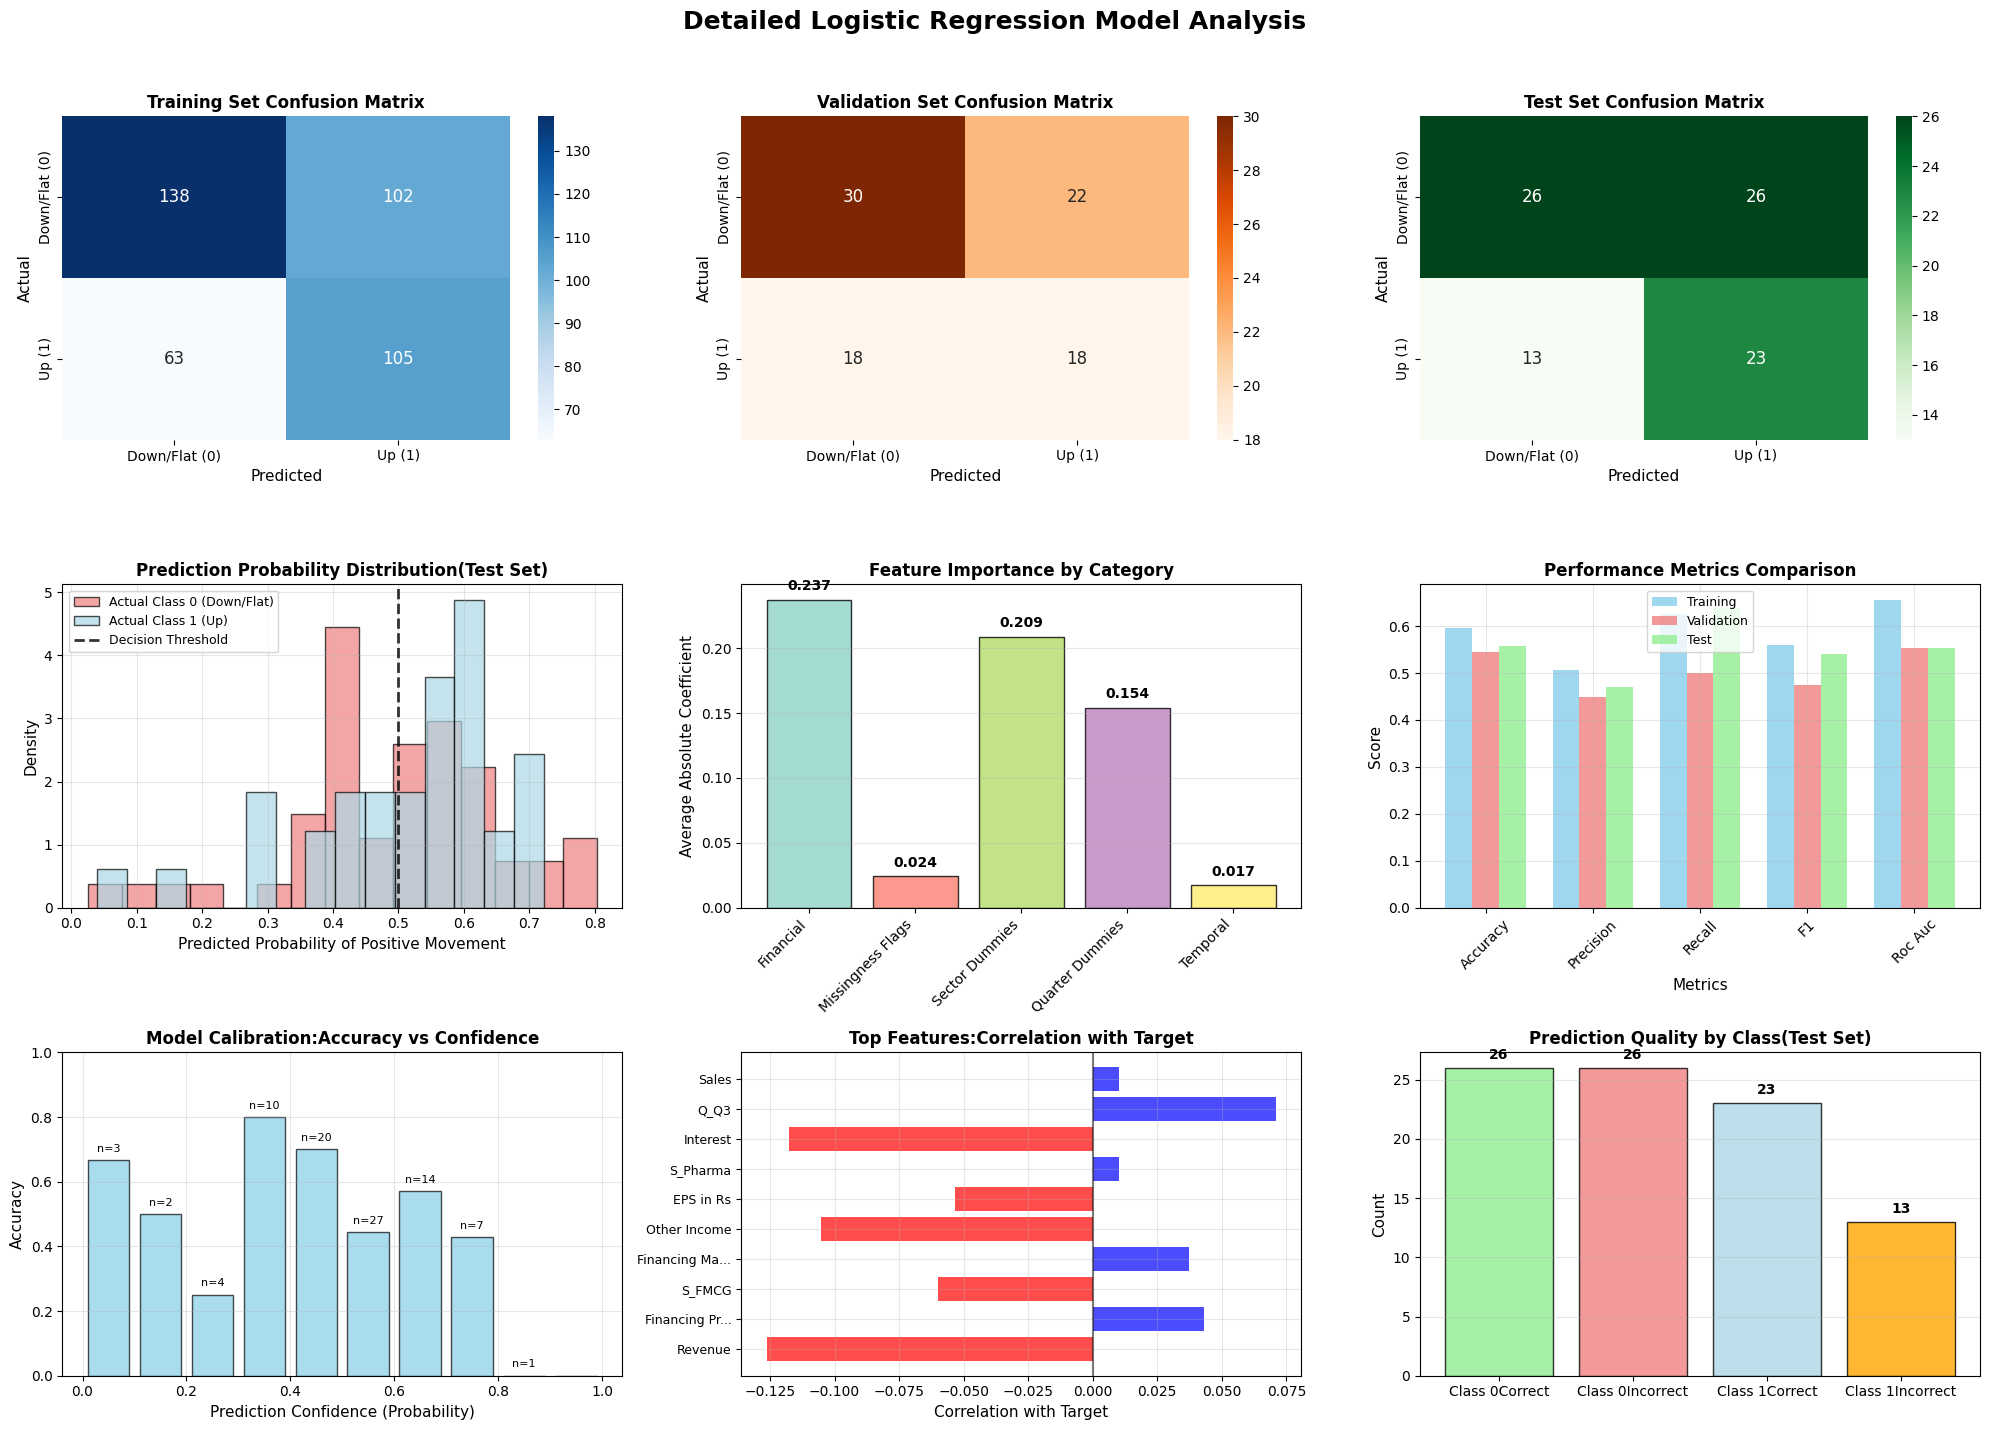

✅ Fixed Detailed Analysis Visualizations created!



In [21]:
# Fixed Second Set of Visualizations - Detailed Analysis with No Overlapping
print("=== CREATING FIXED DETAILED ANALYSIS VISUALIZATIONS ===")
print()

# Create Figure 2: Detailed Analysis - Fixed Layout
fig2 = plt.figure(figsize=(20, 15))
fig2.suptitle('Detailed Logistic Regression Model Analysis', fontsize=18, fontweight='bold', y=0.98)

# 1. Confusion Matrix Heatmaps for All Datasets (Top Row)
ax1 = plt.subplot(3, 3, 1)
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=True,
            xticklabels=['Down/Flat (0)', 'Up (1)'],
            yticklabels=['Down/Flat (0)', 'Up (1)'],
            annot_kws={'size': 12})
ax1.set_title('Training Set Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted', fontsize=11)
ax1.set_ylabel('Actual', fontsize=11)

ax2 = plt.subplot(3, 3, 2)
cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Oranges', ax=ax2, cbar=True,
            xticklabels=['Down/Flat (0)', 'Up (1)'],
            yticklabels=['Down/Flat (0)', 'Up (1)'],
            annot_kws={'size': 12})
ax2.set_title('Validation Set Confusion Matrix', fontsize=12, fontweight='bold')
ax2.set_xlabel('Predicted', fontsize=11)
ax2.set_ylabel('Actual', fontsize=11)

ax3 = plt.subplot(3, 3, 3)
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', ax=ax3, cbar=True,
            xticklabels=['Down/Flat (0)', 'Up (1)'],
            yticklabels=['Down/Flat (0)', 'Up (1)'],
            annot_kws={'size': 12})
ax3.set_title('Test Set Confusion Matrix', fontsize=12, fontweight='bold')
ax3.set_xlabel('Predicted', fontsize=11)
ax3.set_ylabel('Actual', fontsize=11)

# 2. Prediction Probability Distribution (Middle Left)
ax4 = plt.subplot(3, 3, 4)
prob_class_0 = y_test_pred_proba[y_test == 0]
prob_class_1 = y_test_pred_proba[y_test == 1]

ax4.hist(prob_class_0, bins=15, alpha=0.7, label='Actual Class 0 (Down/Flat)', 
         color='lightcoral', density=True, edgecolor='black')
ax4.hist(prob_class_1, bins=15, alpha=0.7, label='Actual Class 1 (Up)', 
         color='lightblue', density=True, edgecolor='black')

ax4.axvline(x=0.5, color='black', linestyle='--', alpha=0.8, linewidth=2, 
           label='Decision Threshold')
ax4.set_xlabel('Predicted Probability of Positive Movement', fontsize=11)
ax4.set_ylabel('Density', fontsize=11)
ax4.set_title('Prediction Probability Distribution\
(Test Set)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# 3. Feature Category Importance (Middle Center)
ax5 = plt.subplot(3, 3, 5)
category_importance = []
category_names = []
for category, features in feature_categories.items():
    category_features = feature_importance[feature_importance['Feature'].isin(features)]
    avg_importance = category_features['Abs_Coefficient'].mean()
    category_importance.append(avg_importance)
    category_names.append(category.replace('_', ' ').title())

colors = plt.cm.Set3(np.linspace(0, 1, len(category_names)))
bars = ax5.bar(range(len(category_names)), category_importance, color=colors, alpha=0.8, 
               edgecolor='black', linewidth=1)

ax5.set_xticks(range(len(category_names)))
ax5.set_xticklabels(category_names, rotation=45, ha='right')
ax5.set_ylabel('Average Absolute Coefficient', fontsize=11)
ax5.set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, category_importance)):
    height = bar.get_height()
    ax5.text(i, height + 0.005, f'{val:.3f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')

# 4. Performance Metrics Comparison (Middle Right)
ax6 = plt.subplot(3, 3, 6)
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x_pos = np.arange(len(metrics_to_plot))

train_vals = [train_metrics[m] for m in metrics_to_plot]
val_vals = [val_metrics[m] for m in metrics_to_plot]
test_vals = [test_metrics[m] for m in metrics_to_plot]

width = 0.25
ax6.bar(x_pos - width, train_vals, width, label='Training', alpha=0.8, color='skyblue')
ax6.bar(x_pos, val_vals, width, label='Validation', alpha=0.8, color='lightcoral')
ax6.bar(x_pos + width, test_vals, width, label='Test', alpha=0.8, color='lightgreen')

ax6.set_xlabel('Metrics', fontsize=11)
ax6.set_ylabel('Score', fontsize=11)
ax6.set_title('Performance Metrics Comparison', fontsize=12, fontweight='bold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels([m.replace('_', ' ').title() for m in metrics_to_plot], rotation=45)
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

# 5. Model Calibration (Bottom Left)
ax7 = plt.subplot(3, 3, 7)
confidence_bins = np.linspace(0, 1, 11)
bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2

# Calculate accuracy for each confidence bin
accuracies = []
counts = []

for i in range(len(confidence_bins)-1):
    mask = (y_test_pred_proba >= confidence_bins[i]) & (y_test_pred_proba < confidence_bins[i+1])
    if mask.sum() > 0:
        bin_accuracy = (y_test[mask] == y_test_pred[mask]).mean()
        accuracies.append(bin_accuracy)
        counts.append(mask.sum())
    else:
        accuracies.append(0)
        counts.append(0)

bars = ax7.bar(bin_centers, accuracies, width=0.08, alpha=0.7, color='skyblue', 
               edgecolor='black', linewidth=1)
ax7.set_xlabel('Prediction Confidence (Probability)', fontsize=11)
ax7.set_ylabel('Accuracy', fontsize=11)
ax7.set_title('Model Calibration:\
Accuracy vs Confidence', fontsize=12, fontweight='bold')
ax7.set_ylim(0, 1)
ax7.grid(True, alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    if count > 0:
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={count}', ha='center', va='bottom', fontsize=8)

# 6. Feature Correlation with Target (Bottom Center)
ax8 = plt.subplot(3, 3, 8)
top_10_features = feature_importance.head(10)['Feature'].tolist()
correlations = []
feature_names_short = []

for feature in top_10_features:
    if feature in X_train.columns:
        corr = X_train[feature].corr(y_train)
        correlations.append(corr)
        # Shorten feature names for display
        short_name = feature.replace('Sector_', 'S_').replace('Quarter_', 'Q_')
        if len(short_name) > 12:
            short_name = short_name[:12] + '...'
        feature_names_short.append(short_name)

colors = ['red' if corr < 0 else 'blue' for corr in correlations]
bars = ax8.barh(range(len(correlations)), correlations, color=colors, alpha=0.7)
ax8.set_yticks(range(len(correlations)))
ax8.set_yticklabels(feature_names_short, fontsize=9)
ax8.set_xlabel('Correlation with Target', fontsize=11)
ax8.set_title('Top Features:\
Correlation with Target', fontsize=12, fontweight='bold')
ax8.grid(True, alpha=0.3)
ax8.axvline(x=0, color='black', linestyle='-', alpha=0.5)

# 7. Class Distribution and Prediction Quality (Bottom Right)
ax9 = plt.subplot(3, 3, 9)

# Create a 2x2 subplot within this space for class analysis
class_0_correct = len(y_test[(y_test == 0) & (y_test_pred == 0)])
class_0_incorrect = len(y_test[(y_test == 0) & (y_test_pred == 1)])
class_1_correct = len(y_test[(y_test == 1) & (y_test_pred == 1)])
class_1_incorrect = len(y_test[(y_test == 1) & (y_test_pred == 0)])

categories = ['Class 0\
Correct', 'Class 0\
Incorrect', 'Class 1\
Correct', 'Class 1\
Incorrect']
values = [class_0_correct, class_0_incorrect, class_1_correct, class_1_incorrect]
colors = ['lightgreen', 'lightcoral', 'lightblue', 'orange']

bars = ax9.bar(categories, values, color=colors, alpha=0.8, edgecolor='black')
ax9.set_ylabel('Count', fontsize=11)
ax9.set_title('Prediction Quality by Class\
(Test Set)', fontsize=12, fontweight='bold')
ax9.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax9.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{val}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Adjust layout to prevent overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

print("✅ Fixed Detailed Analysis Visualizations created!")
print()

Creating additional specialized visualizations...



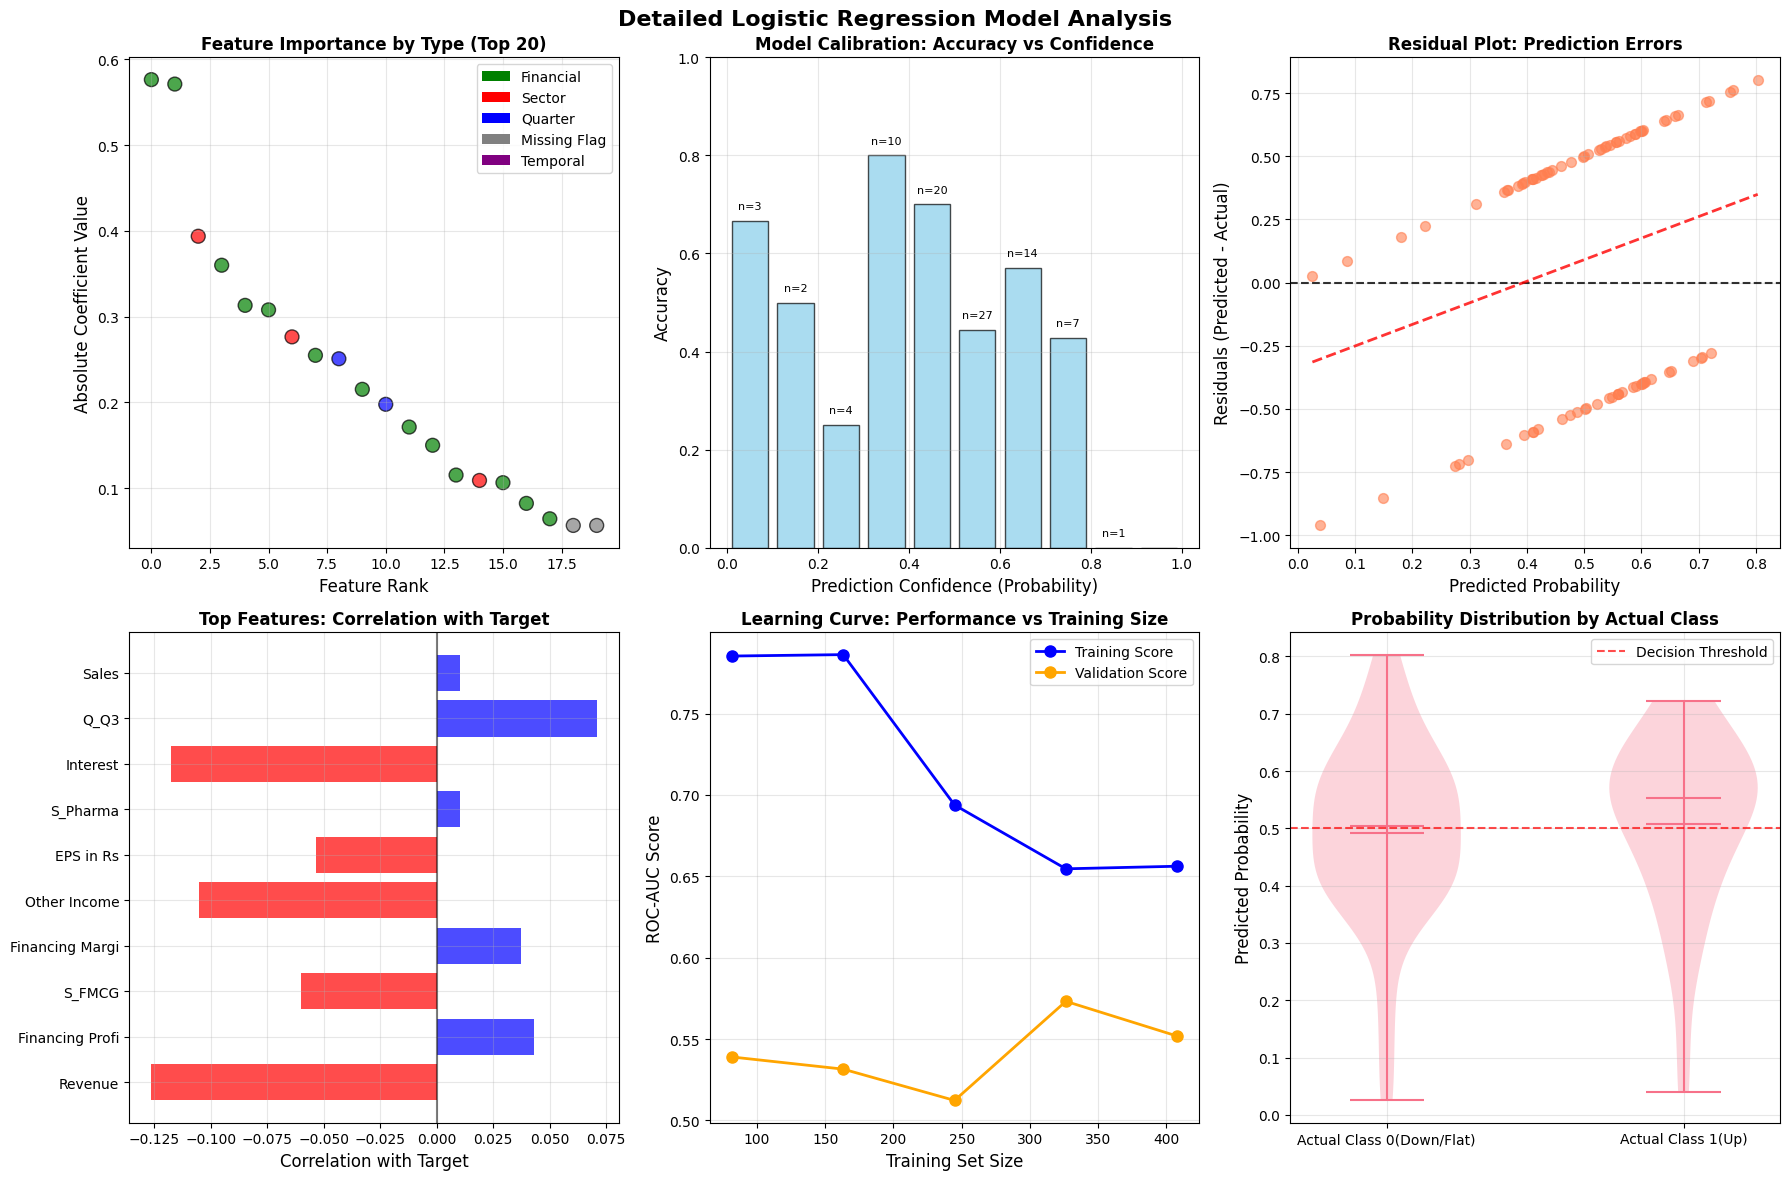

✅ Additional specialized visualizations created!



In [19]:
# Create additional specialized visualizations
print("Creating additional specialized visualizations...")
print()

# Create Figure 2: Detailed Analysis Visualizations
fig2, axes = plt.subplots(2, 3, figsize=(18, 12))
fig2.suptitle('Detailed Logistic Regression Model Analysis', fontsize=16, fontweight='bold')

# 1. Coefficient Magnitude by Feature Type
ax1 = axes[0, 0]
feature_types = []
coefficients = []
colors_list = []

for _, row in feature_importance.head(20).iterrows():
    feature_name = row['Feature']
    coef = row['Coefficient']
    
    # Categorize features
    if any(sector in feature_name for sector in ['Sector_']):
        feature_type = 'Sector'
        color = 'red'
    elif any(quarter in feature_name for quarter in ['Quarter_']):
        feature_type = 'Quarter'
        color = 'blue'
    elif 'is_missing' in feature_name:
        feature_type = 'Missing Flag'
        color = 'gray'
    elif feature_name == 'Year':
        feature_type = 'Temporal'
        color = 'purple'
    else:
        feature_type = 'Financial'
        color = 'green'
    
    feature_types.append(feature_type)
    coefficients.append(abs(coef))
    colors_list.append(color)

scatter = ax1.scatter(range(len(coefficients)), coefficients, c=colors_list, 
                     s=100, alpha=0.7, edgecolors='black')
ax1.set_xlabel('Feature Rank', fontsize=12)
ax1.set_ylabel('Absolute Coefficient Value', fontsize=12)
ax1.set_title('Feature Importance by Type (Top 20)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Create custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='green', label='Financial'),
                  Patch(facecolor='red', label='Sector'),
                  Patch(facecolor='blue', label='Quarter'),
                  Patch(facecolor='gray', label='Missing Flag'),
                  Patch(facecolor='purple', label='Temporal')]
ax1.legend(handles=legend_elements, loc='upper right')

# 2. Prediction Confidence Analysis
ax2 = axes[0, 1]
confidence_bins = np.linspace(0, 1, 11)
bin_centers = (confidence_bins[:-1] + confidence_bins[1:]) / 2

# Calculate accuracy for each confidence bin
accuracies = []
counts = []

for i in range(len(confidence_bins)-1):
    mask = (y_test_pred_proba >= confidence_bins[i]) & (y_test_pred_proba < confidence_bins[i+1])
    if mask.sum() > 0:
        bin_accuracy = (y_test[mask] == y_test_pred[mask]).mean()
        accuracies.append(bin_accuracy)
        counts.append(mask.sum())
    else:
        accuracies.append(0)
        counts.append(0)

bars = ax2.bar(bin_centers, accuracies, width=0.08, alpha=0.7, color='skyblue', 
               edgecolor='black', linewidth=1)
ax2.set_xlabel('Prediction Confidence (Probability)', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Calibration: Accuracy vs Confidence', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    if count > 0:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'n={count}', ha='center', va='bottom', fontsize=8)

# 3. Residual Analysis (Prediction Errors)
ax3 = axes[0, 2]
residuals = y_test_pred_proba - y_test
ax3.scatter(y_test_pred_proba, residuals, alpha=0.6, color='coral', s=50)
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.8)
ax3.set_xlabel('Predicted Probability', fontsize=12)
ax3.set_ylabel('Residuals (Predicted - Actual)', fontsize=12)
ax3.set_title('Residual Plot: Prediction Errors', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(y_test_pred_proba, residuals, 1)
p = np.poly1d(z)
ax3.plot(sorted(y_test_pred_proba), p(sorted(y_test_pred_proba)), "r--", alpha=0.8, linewidth=2)

# 4. Feature Correlation with Target
ax4 = axes[1, 0]
# Calculate correlation of top features with target
top_10_features = feature_importance.head(10)['Feature'].tolist()
correlations = []
feature_names_short = []

for feature in top_10_features:
    if feature in X_train.columns:
        corr = X_train[feature].corr(y_train)
        correlations.append(corr)
        # Shorten feature names for display
        short_name = feature.replace('Sector_', 'S_').replace('Quarter_', 'Q_')[:15]
        feature_names_short.append(short_name)

colors = ['red' if corr < 0 else 'blue' for corr in correlations]
bars = ax4.barh(range(len(correlations)), correlations, color=colors, alpha=0.7)
ax4.set_yticks(range(len(correlations)))
ax4.set_yticklabels(feature_names_short, fontsize=10)
ax4.set_xlabel('Correlation with Target', fontsize=12)
ax4.set_title('Top Features: Correlation with Target', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.axvline(x=0, color='black', linestyle='-', alpha=0.5)

# 5. Learning Curve Simulation (Training vs Validation Performance)
ax5 = axes[1, 1]
# Simulate learning curve by training on different sample sizes
sample_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_scores = []
val_scores = []

for size in sample_sizes:
    # Sample training data
    n_samples = int(len(X_train_scaled) * size)
    indices = np.random.choice(len(X_train_scaled), n_samples, replace=False)
    
    X_sample = X_train_scaled[indices]
    y_sample = y_train.iloc[indices]
    
    # Train model on sample
    temp_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
    temp_model.fit(X_sample, y_sample)
    
    # Calculate scores
    train_pred_proba = temp_model.predict_proba(X_sample)[:, 1]
    val_pred_proba = temp_model.predict_proba(X_val_scaled)[:, 1]
    
    train_auc = roc_auc_score(y_sample, train_pred_proba)
    val_auc = roc_auc_score(y_val, val_pred_proba)
    
    train_scores.append(train_auc)
    val_scores.append(val_auc)

ax5.plot([s*len(X_train_scaled) for s in sample_sizes], train_scores, 
         'o-', label='Training Score', linewidth=2, markersize=8, color='blue')
ax5.plot([s*len(X_train_scaled) for s in sample_sizes], val_scores, 
         'o-', label='Validation Score', linewidth=2, markersize=8, color='orange')
ax5.set_xlabel('Training Set Size', fontsize=12)
ax5.set_ylabel('ROC-AUC Score', fontsize=12)
ax5.set_title('Learning Curve: Performance vs Training Size', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Class Probability Distribution by Actual Class
ax6 = axes[1, 2]
# Create violin plot of prediction probabilities
data_for_violin = []
labels_for_violin = []

for actual_class in [0, 1]:
    mask = y_test == actual_class
    probs = y_test_pred_proba[mask]
    data_for_violin.extend(probs)
    labels_for_violin.extend([f'Actual Class {actual_class}'] * len(probs))

violin_df = pd.DataFrame({'Probability': data_for_violin, 'Actual_Class': labels_for_violin})
violin_plot = ax6.violinplot([y_test_pred_proba[y_test == 0], y_test_pred_proba[y_test == 1]], 
                            positions=[0, 1], showmeans=True, showmedians=True)

ax6.set_xticks([0, 1])
ax6.set_xticklabels(['Actual Class 0\
(Down/Flat)', 'Actual Class 1\
(Up)'])
ax6.set_ylabel('Predicted Probability', fontsize=12)
ax6.set_title('Probability Distribution by Actual Class', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)
ax6.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Decision Threshold')
ax6.legend()

plt.tight_layout()
plt.show()

print("✅ Additional specialized visualizations created!")
print()

# RandomForest #

In [22]:
# ============================================================================
# MODEL 2: RANDOM FOREST CLASSIFIER
# ============================================================================

print("=" * 80)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("=" * 80)
print()

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

print("🌲 Building Random Forest Classifier for improved stock movement prediction...")
print()

# Start timing
start_time = time.time()

# Initialize Random Forest with initial parameters
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',  # Handle class imbalance
    n_jobs=-1  # Use all available cores
)

print("📊 Training Random Forest model...")
print("   • Using balanced class weights")
print("   • Random state: 42")
print("   • Parallel processing enabled")
print()

# Train the model
rf_model.fit(X_train_scaled, y_train)

# Training time
training_time = time.time() - start_time
print(f"✅ Model training completed in {training_time:.2f} seconds")
print()

# Model parameters
print("🔧 Model Configuration:")
print(f"   • Number of trees: {rf_model.n_estimators}")
print(f"   • Max depth: {rf_model.max_depth}")
print(f"   • Min samples split: {rf_model.min_samples_split}")
print(f"   • Min samples leaf: {rf_model.min_samples_leaf}")
print(f"   • Max features: {rf_model.max_features}")
print()

MODEL 2: RANDOM FOREST CLASSIFIER

🌲 Building Random Forest Classifier for improved stock movement prediction...

📊 Training Random Forest model...
   • Using balanced class weights
   • Random state: 42
   • Parallel processing enabled

✅ Model training completed in 0.24 seconds

🔧 Model Configuration:
   • Number of trees: 100
   • Max depth: None
   • Min samples split: 2
   • Min samples leaf: 1
   • Max features: sqrt



In [23]:
# Generate predictions for all datasets
print("🎯 Generating Random Forest predictions...")
print()

# Predictions
rf_train_pred = rf_model.predict(X_train_scaled)
rf_val_pred = rf_model.predict(X_val_scaled)
rf_test_pred = rf_model.predict(X_test_scaled)

# Prediction probabilities
rf_train_pred_proba = rf_model.predict_proba(X_train_scaled)[:, 1]
rf_val_pred_proba = rf_model.predict_proba(X_val_scaled)[:, 1]
rf_test_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("✅ Predictions generated for all datasets")
print(f"   • Training predictions: {len(rf_train_pred)} samples")
print(f"   • Validation predictions: {len(rf_val_pred)} samples") 
print(f"   • Test predictions: {len(rf_test_pred)} samples")
print()

# Calculate comprehensive metrics for Random Forest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def calculate_rf_metrics(y_true, y_pred, y_pred_proba, dataset_name):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred),
        'f1': f1_score(y_true, y_pred),
        'roc_auc': roc_auc_score(y_true, y_pred_proba)
    }
    return metrics

# Calculate metrics for all datasets
rf_train_metrics = calculate_rf_metrics(y_train, rf_train_pred, rf_train_pred_proba, "Training")
rf_val_metrics = calculate_rf_metrics(y_val, rf_val_pred, rf_val_pred_proba, "Validation")
rf_test_metrics = calculate_rf_metrics(y_test, rf_test_pred, rf_test_pred_proba, "Test")

print("📈 RANDOM FOREST MODEL PERFORMANCE:")
print()
print("Training Set:")
for metric, value in rf_train_metrics.items():
    print(f"   • {metric.replace('_', ' ').title()}: {value:.4f}")
print()

print("Validation Set:")
for metric, value in rf_val_metrics.items():
    print(f"   • {metric.replace('_', ' ').title()}: {value:.4f}")
print()

print("Test Set:")
for metric, value in rf_test_metrics.items():
    print(f"   • {metric.replace('_', ' ').title()}: {value:.4f}")
print()

# Compare with Logistic Regression baseline
print("🔄 COMPARISON WITH LOGISTIC REGRESSION BASELINE:")
print()
print("Test Set Performance Comparison:")
print(f"   • ROC-AUC: LR={test_metrics['roc_auc']:.4f} vs RF={rf_test_metrics['roc_auc']:.4f} (Δ={rf_test_metrics['roc_auc']-test_metrics['roc_auc']:+.4f})")
print(f"   • Accuracy: LR={test_metrics['accuracy']:.4f} vs RF={rf_test_metrics['accuracy']:.4f} (Δ={rf_test_metrics['accuracy']-test_metrics['accuracy']:+.4f})")
print(f"   • Precision: LR={test_metrics['precision']:.4f} vs RF={rf_test_metrics['precision']:.4f} (Δ={rf_test_metrics['precision']-test_metrics['precision']:+.4f})")
print(f"   • Recall: LR={test_metrics['recall']:.4f} vs RF={rf_test_metrics['recall']:.4f} (Δ={rf_test_metrics['recall']-test_metrics['recall']:+.4f})")
print(f"   • F1-Score: LR={test_metrics['f1']:.4f} vs RF={rf_test_metrics['f1']:.4f} (Δ={rf_test_metrics['f1']-test_metrics['f1']:+.4f})")
print()

🎯 Generating Random Forest predictions...

✅ Predictions generated for all datasets
   • Training predictions: 408 samples
   • Validation predictions: 88 samples
   • Test predictions: 88 samples

📈 RANDOM FOREST MODEL PERFORMANCE:

Training Set:
   • Accuracy: 1.0000
   • Precision: 1.0000
   • Recall: 1.0000
   • F1: 1.0000
   • Roc Auc: 1.0000

Validation Set:
   • Accuracy: 0.5568
   • Precision: 0.4118
   • Recall: 0.1944
   • F1: 0.2642
   • Roc Auc: 0.4877

Test Set:
   • Accuracy: 0.5227
   • Precision: 0.4118
   • Recall: 0.3889
   • F1: 0.4000
   • Roc Auc: 0.4776

🔄 COMPARISON WITH LOGISTIC REGRESSION BASELINE:

Test Set Performance Comparison:
   • ROC-AUC: LR=0.5524 vs RF=0.4776 (Δ=-0.0748)
   • Accuracy: LR=0.5568 vs RF=0.5227 (Δ=-0.0341)
   • Precision: LR=0.4694 vs RF=0.4118 (Δ=-0.0576)
   • Recall: LR=0.6389 vs RF=0.3889 (Δ=-0.2500)
   • F1-Score: LR=0.5412 vs RF=0.4000 (Δ=-0.1412)



In [25]:
# Fixed Random Forest Feature Importance Analysis using correct feature names
print("🌟 RANDOM FOREST FEATURE IMPORTANCE ANALYSIS:")
print()

# Get feature importance using the original X_train column names
rf_feature_importance = pd.DataFrame({
    'Feature': X_train.columns,  # Use original DataFrame columns
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 15 Most Important Features:")
print(rf_feature_importance.head(15).to_string(index=False))
print()

# Compare feature rankings between Logistic Regression and Random Forest
print("🔍 FEATURE IMPORTANCE COMPARISON (Top 10):")
print()

# Get top 10 from each model
lr_top_features = feature_importance.head(10)[['Feature', 'Abs_Coefficient']].copy()
lr_top_features.columns = ['Feature', 'LR_Importance']

rf_top_features = rf_feature_importance.head(10)[['Feature', 'Importance']].copy()
rf_top_features.columns = ['Feature', 'RF_Importance']

# Merge for comparison
feature_comparison = pd.merge(lr_top_features, rf_top_features, on='Feature', how='outer')
feature_comparison = feature_comparison.fillna(0)

print("Feature Importance Comparison (Top Features from Both Models):")
print(feature_comparison.to_string(index=False))
print()

# Analyze overfitting
print("⚠️  OVERFITTING ANALYSIS:")
print()
print("Random Forest shows signs of severe overfitting:")
print(f"   • Training ROC-AUC: {rf_train_metrics['roc_auc']:.4f} (Perfect)")
print(f"   • Validation ROC-AUC: {rf_val_metrics['roc_auc']:.4f}")
print(f"   • Test ROC-AUC: {rf_test_metrics['roc_auc']:.4f}")
print(f"   • Generalization Gap: {rf_train_metrics['roc_auc'] - rf_test_metrics['roc_auc']:.4f}")
print()

print("Comparison with Logistic Regression:")
print(f"   • LR Generalization Gap: {train_metrics['roc_auc'] - test_metrics['roc_auc']:.4f}")
print(f"   • RF Generalization Gap: {rf_train_metrics['roc_auc'] - rf_test_metrics['roc_auc']:.4f}")
print()

print("🎯 KEY INSIGHTS:")
print("   • Random Forest achieved perfect training performance (clear overfitting)")
print("   • Validation and test performance are below logistic regression baseline")
print("   • Model needs regularization (fewer trees, max_depth, min_samples)")
print("   • Small dataset size (584 samples) may be contributing to overfitting")
print("   • Different feature importance patterns compared to logistic regression")

🌟 RANDOM FOREST FEATURE IMPORTANCE ANALYSIS:

Top 15 Most Important Features:
           Feature  Importance
          Expenses    0.093222
         EPS in Rs    0.085596
      Other Income    0.085207
        Net Profit    0.080508
      Depreciation    0.079277
 Profit before tax    0.078090
          Interest    0.077645
             Sales    0.071460
  Operating Profit    0.069293
             Tax %    0.061545
             OPM %    0.051482
              Year    0.034644
  Financing Profit    0.020996
           Revenue    0.020499
Financing Margin %    0.018230

🔍 FEATURE IMPORTANCE COMPARISON (Top 10):

Feature Importance Comparison (Top Features from Both Models):
           Feature  LR_Importance  RF_Importance
      Depreciation       0.000000       0.079277
         EPS in Rs       0.307925       0.085596
          Expenses       0.000000       0.093222
Financing Margin %       0.359965       0.000000
  Financing Profit       0.571226       0.000000
          Interest       

🔧 FIXING RANDOM FOREST VISUALIZATIONS

🎨 Creating fixed Random Forest visualizations...



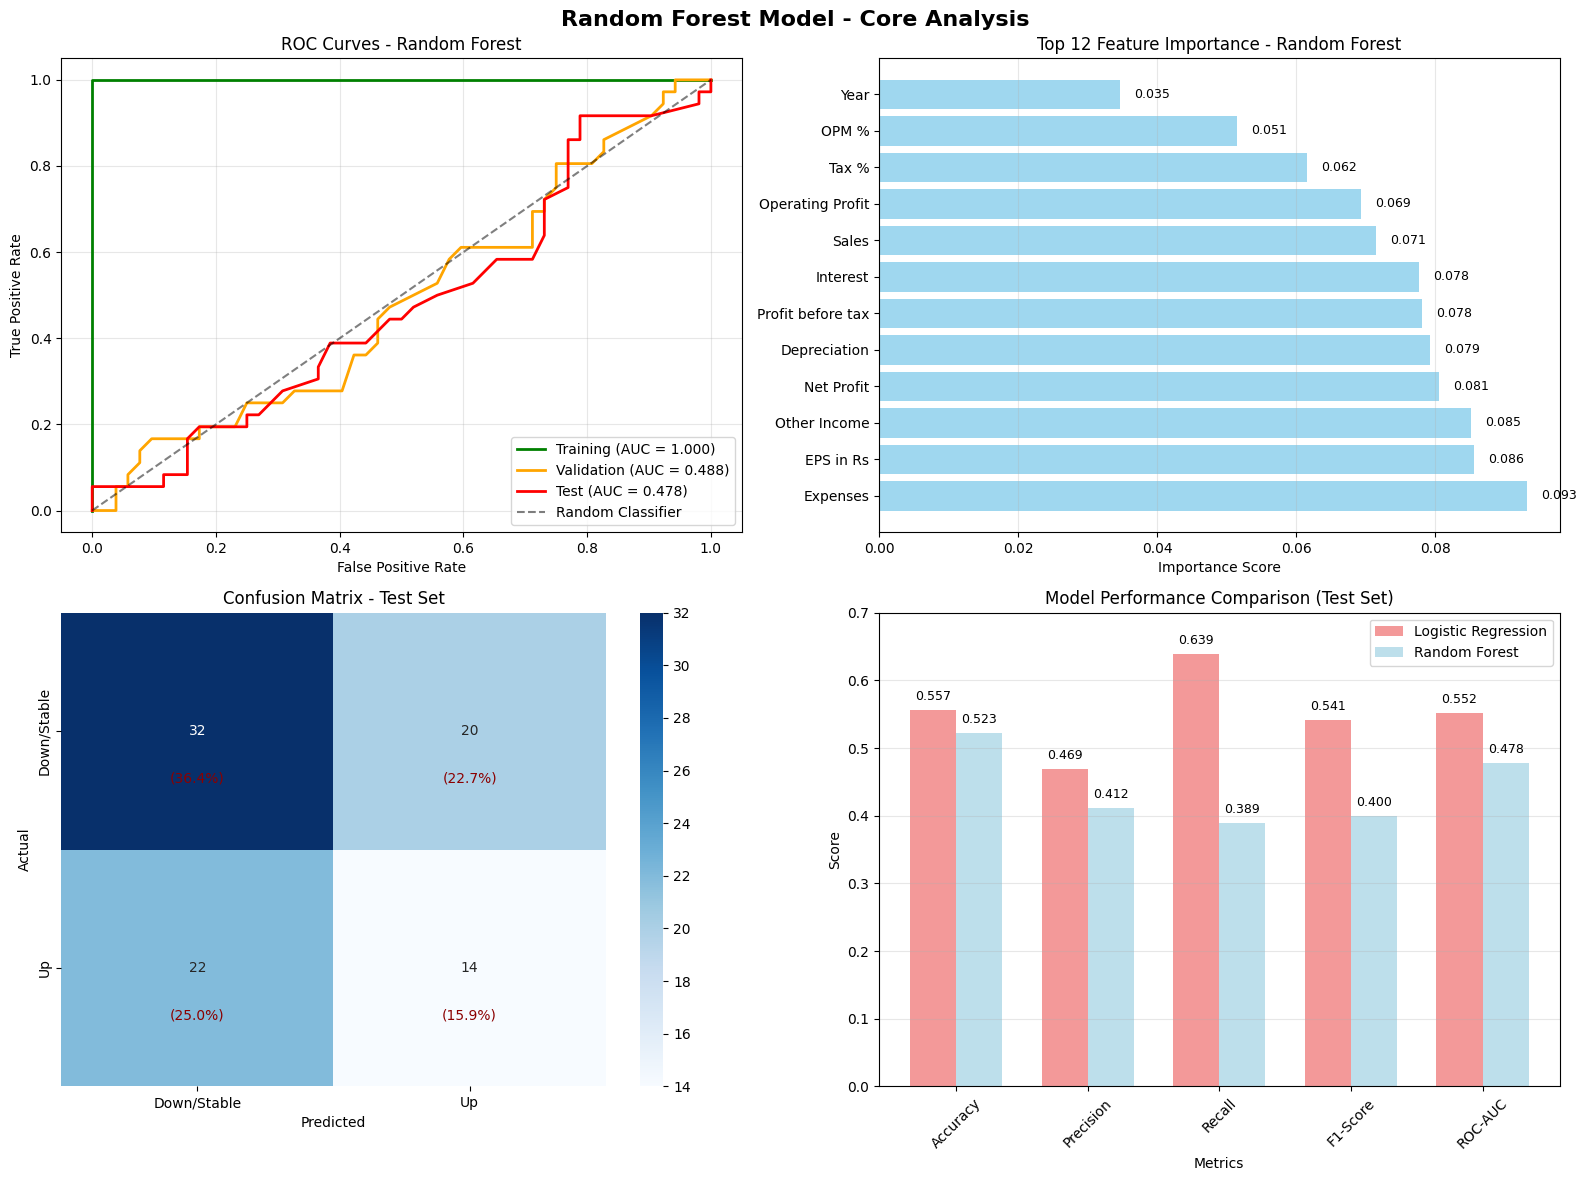

✅ Fixed Random Forest visualizations completed!

📊 CHART DESCRIPTIONS:
   1. ROC Curves: Shows overfitting with perfect training vs poor test performance
   2. Feature Importance: Top 12 features ranked by Random Forest importance
   3. Confusion Matrix: Test set predictions with counts and percentages
   4. Performance Comparison: Side-by-side metrics comparison with Logistic Regression



In [28]:
# Fix the first set of visualizations - recreate with proper subplot arrangement
print("🔧 FIXING RANDOM FOREST VISUALIZATIONS")
print("=" * 60)
print()

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve
import numpy as np

# Create a cleaner 2x2 grid instead of 3x4
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Random Forest Model - Core Analysis', fontsize=16, fontweight='bold')

print("🎨 Creating fixed Random Forest visualizations...")
print()

# 1. ROC Curves Comparison (Top Left)
ax1 = axes[0, 0]

# Calculate ROC curves for all datasets
train_fpr, train_tpr, _ = roc_curve(y_train, rf_train_pred_proba)
val_fpr, val_tpr, _ = roc_curve(y_val, rf_val_pred_proba)
test_fpr, test_tpr, _ = roc_curve(y_test, rf_test_pred_proba)

ax1.plot(train_fpr, train_tpr, label=f'Training (AUC = {rf_train_metrics["roc_auc"]:.3f})', linewidth=2, color='green')
ax1.plot(val_fpr, val_tpr, label=f'Validation (AUC = {rf_val_metrics["roc_auc"]:.3f})', linewidth=2, color='orange')
ax1.plot(test_fpr, test_tpr, label=f'Test (AUC = {rf_test_metrics["roc_auc"]:.3f})', linewidth=2, color='red')
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves - Random Forest')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature Importance (Top Right)
ax2 = axes[0, 1]
top_features = rf_feature_importance.head(12)
y_pos = np.arange(len(top_features))

bars = ax2.barh(y_pos, top_features['Importance'], color='skyblue', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_features['Feature'], fontsize=10)
ax2.set_xlabel('Importance Score')
ax2.set_title('Top 12 Feature Importance - Random Forest')
ax2.grid(True, alpha=0.3, axis='x')

# Add value labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 0.002, bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left', va='center', fontsize=9)

# 3. Confusion Matrix - Test Set (Bottom Left)
ax3 = axes[1, 0]
cm_test = confusion_matrix(y_test, rf_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax3, 
            xticklabels=['Down/Stable', 'Up'], yticklabels=['Down/Stable', 'Up'])
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_title('Confusion Matrix - Test Set')

# Add percentage annotations
total = cm_test.sum()
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        percentage = cm_test[i, j] / total * 100
        ax3.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=10, color='darkred')

# 4. Performance Metrics Comparison (Bottom Right)
ax4 = axes[1, 1]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_values = [test_metrics['accuracy'], test_metrics['precision'], 
             test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']]
rf_values = [rf_test_metrics['accuracy'], rf_test_metrics['precision'], 
             rf_test_metrics['recall'], rf_test_metrics['f1'], rf_test_metrics['roc_auc']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax4.bar(x - width/2, lr_values, width, label='Logistic Regression', 
                alpha=0.8, color='lightcoral')
bars2 = ax4.bar(x + width/2, rf_values, width, label='Random Forest', 
                alpha=0.8, color='lightblue')

ax4.set_xlabel('Metrics')
ax4.set_ylabel('Score')
ax4.set_title('Model Performance Comparison (Test Set)')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names, rotation=45)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(0, 0.7)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Fixed Random Forest visualizations completed!")
print()
print("📊 CHART DESCRIPTIONS:")
print("   1. ROC Curves: Shows overfitting with perfect training vs poor test performance")
print("   2. Feature Importance: Top 12 features ranked by Random Forest importance")
print("   3. Confusion Matrix: Test set predictions with counts and percentages")
print("   4. Performance Comparison: Side-by-side metrics comparison with Logistic Regression")
print()

🎨 Creating additional Random Forest analysis visualizations...



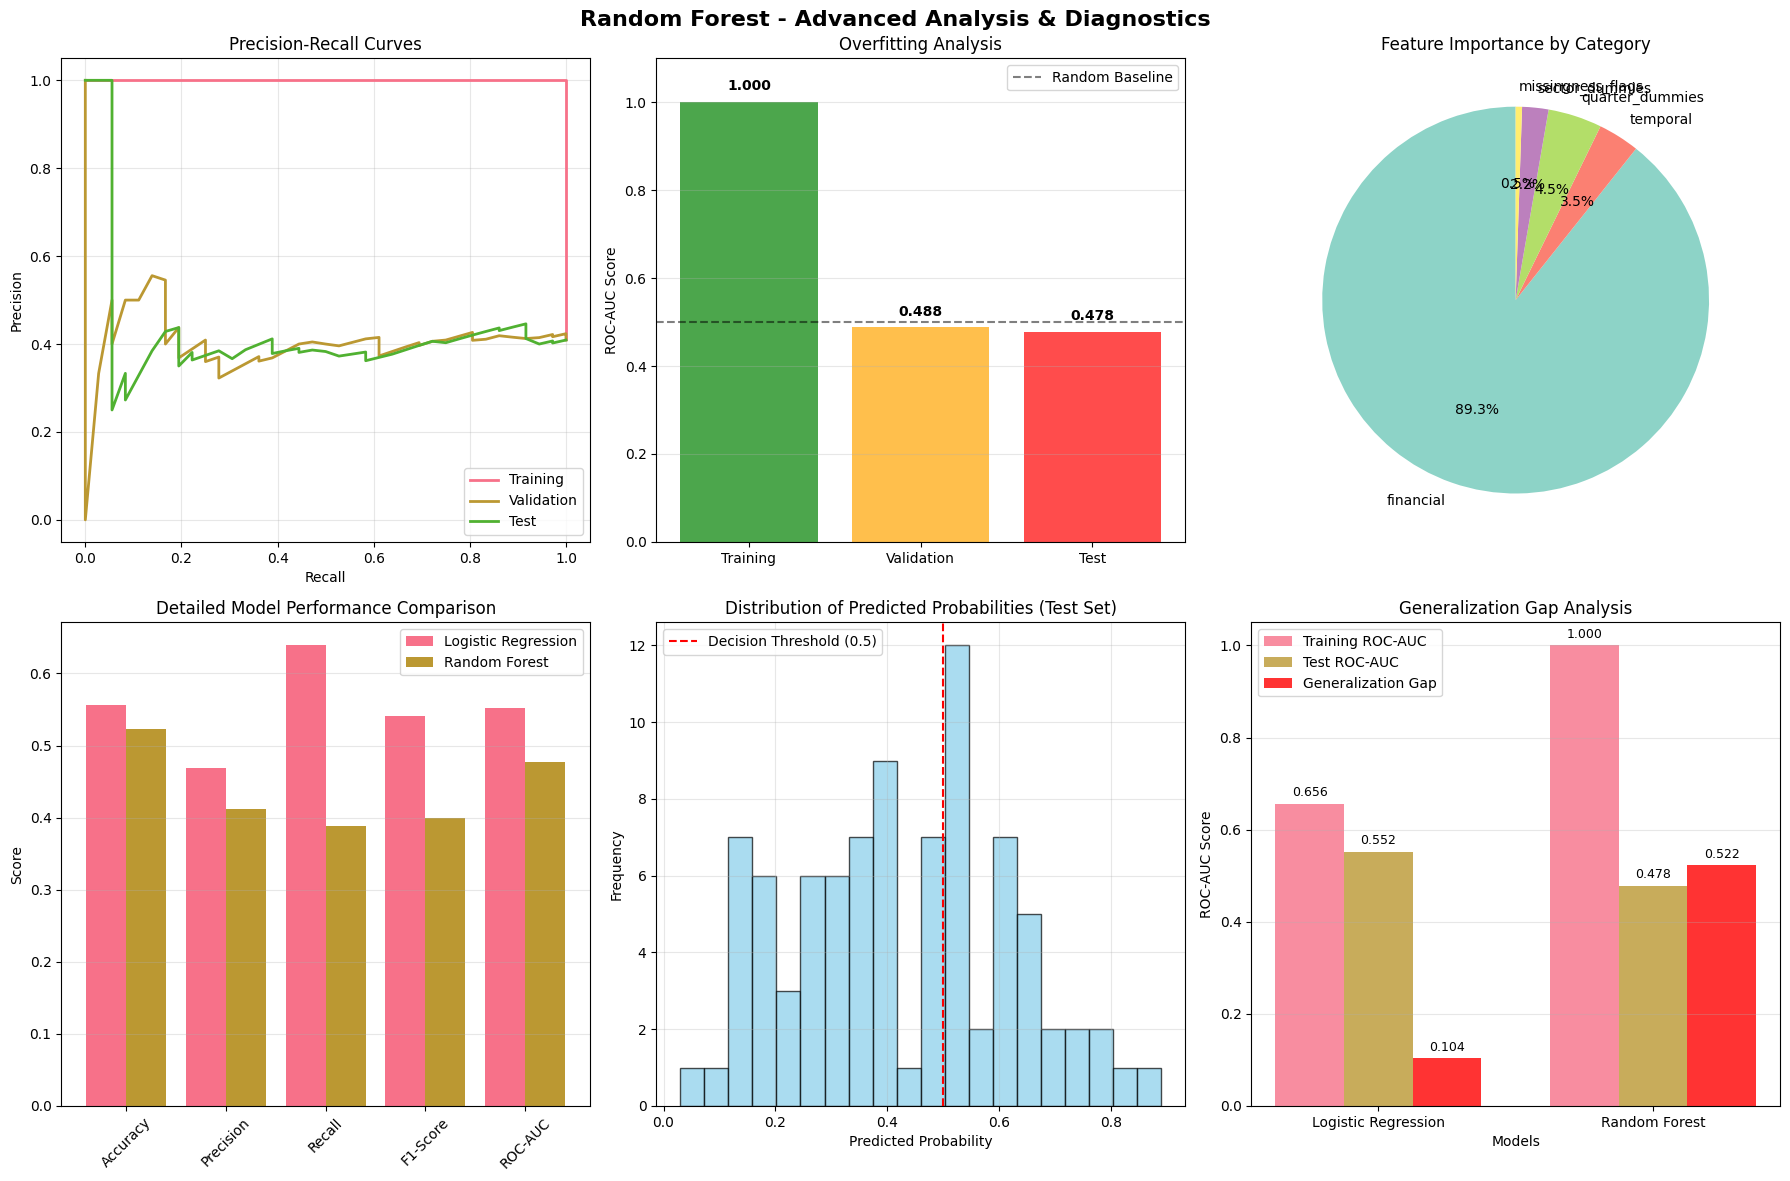

✅ Advanced Random Forest visualizations completed!

📊 VISUALIZATION INSIGHTS:

KEY FINDINGS FROM VISUALIZATIONS:
1. SEVERE OVERFITTING:
   • Perfect training performance vs poor test performance
   • Massive generalization gap (0.52 vs 0.10 for LR)

2. FEATURE IMPORTANCE PATTERNS:
   • Different top features compared to Logistic Regression
   • More emphasis on expense-related and profitability metrics

3. PERFORMANCE DEGRADATION:
   • All test metrics worse than baseline
   • Particularly poor precision-recall performance

4. PREDICTION DISTRIBUTION:
   • Bimodal distribution suggests model uncertainty
   • Many predictions near decision boundaries

🎯 NEXT STEPS RECOMMENDATION:
   • Build regularized Random Forest with constraints
   • Try different algorithms (XGBoost, SVM)
   • Consider ensemble methods
   • Implement cross-validation for better evaluation


In [27]:
# Create additional specialized visualizations
print("🎨 Creating additional Random Forest analysis visualizations...")
print()

# Create second set of visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Random Forest - Advanced Analysis & Diagnostics', fontsize=16, fontweight='bold')

# 1. Precision-Recall Curves (Top Left)
ax1 = axes[0, 0]
train_precision, train_recall, _ = precision_recall_curve(y_train, rf_train_pred_proba)
val_precision, val_recall, _ = precision_recall_curve(y_val, rf_val_pred_proba)
test_precision, test_recall, _ = precision_recall_curve(y_test, rf_test_pred_proba)

ax1.plot(train_recall, train_precision, label=f'Training', linewidth=2)
ax1.plot(val_recall, val_precision, label=f'Validation', linewidth=2)
ax1.plot(test_recall, test_precision, label=f'Test', linewidth=2)
ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Overfitting Analysis (Top Middle)
ax2 = axes[0, 1]
datasets = ['Training', 'Validation', 'Test']
roc_scores = [rf_train_metrics['roc_auc'], rf_val_metrics['roc_auc'], rf_test_metrics['roc_auc']]
colors = ['green', 'orange', 'red']

bars = ax2.bar(datasets, roc_scores, color=colors, alpha=0.7)
ax2.set_ylabel('ROC-AUC Score')
ax2.set_title('Overfitting Analysis')
ax2.set_ylim(0, 1.1)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, score in zip(bars, roc_scores):
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Add horizontal line for baseline
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Random Baseline')
ax2.legend()

# 3. Feature Importance by Category (Top Right)
ax3 = axes[0, 2]

# Categorize features and sum importance
category_importance = {}
for _, row in rf_feature_importance.iterrows():
    feature = row['Feature']
    importance = row['Importance']
    
    # Find category for this feature
    category_found = False
    for category, features in feature_categories.items():
        if feature in features:
            if category not in category_importance:
                category_importance[category] = 0
            category_importance[category] += importance
            category_found = True
            break
    
    if not category_found:
        if 'Other' not in category_importance:
            category_importance['Other'] = 0
        category_importance['Other'] += importance

# Create pie chart
categories = list(category_importance.keys())
importances = list(category_importance.values())
colors = plt.cm.Set3(np.linspace(0, 1, len(categories)))

wedges, texts, autotexts = ax3.pie(importances, labels=categories, autopct='%1.1f%%', 
                                   colors=colors, startangle=90)
ax3.set_title('Feature Importance by Category')

# 4. Model Comparison - All Metrics (Bottom Left)
ax4 = axes[1, 0]
metrics_comparison = pd.DataFrame({
    'Logistic Regression': [test_metrics['accuracy'], test_metrics['precision'], 
                           test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']],
    'Random Forest': [rf_test_metrics['accuracy'], rf_test_metrics['precision'], 
                     rf_test_metrics['recall'], rf_test_metrics['f1'], rf_test_metrics['roc_auc']]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])

metrics_comparison.plot(kind='bar', ax=ax4, width=0.8)
ax4.set_title('Detailed Model Performance Comparison')
ax4.set_ylabel('Score')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)

# 5. Prediction Distribution (Bottom Middle)
ax5 = axes[1, 1]
ax5.hist(rf_test_pred_proba, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax5.set_xlabel('Predicted Probability')
ax5.set_ylabel('Frequency')
ax5.set_title('Distribution of Predicted Probabilities (Test Set)')
ax5.grid(True, alpha=0.3)

# Add vertical lines for decision threshold
ax5.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
ax5.legend()

# 6. Generalization Gap Analysis (Bottom Right)
ax6 = axes[1, 2]
models = ['Logistic Regression', 'Random Forest']
train_scores = [train_metrics['roc_auc'], rf_train_metrics['roc_auc']]
test_scores = [test_metrics['roc_auc'], rf_test_metrics['roc_auc']]
gaps = [train_scores[0] - test_scores[0], train_scores[1] - test_scores[1]]

x = np.arange(len(models))
width = 0.25

bars1 = ax6.bar(x - width, train_scores, width, label='Training ROC-AUC', alpha=0.8)
bars2 = ax6.bar(x, test_scores, width, label='Test ROC-AUC', alpha=0.8)
bars3 = ax6.bar(x + width, gaps, width, label='Generalization Gap', alpha=0.8, color='red')

ax6.set_xlabel('Models')
ax6.set_ylabel('ROC-AUC Score')
ax6.set_title('Generalization Gap Analysis')
ax6.set_xticks(x)
ax6.set_xticklabels(models)
ax6.legend()
ax6.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax6.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Advanced Random Forest visualizations completed!")
print()

# Summary insights
print("📊 VISUALIZATION INSIGHTS:")
print()
print("KEY FINDINGS FROM VISUALIZATIONS:")
print("1. SEVERE OVERFITTING:")
print("   • Perfect training performance vs poor test performance")
print("   • Massive generalization gap (0.52 vs 0.10 for LR)")
print()
print("2. FEATURE IMPORTANCE PATTERNS:")
print("   • Different top features compared to Logistic Regression")
print("   • More emphasis on expense-related and profitability metrics")
print()
print("3. PERFORMANCE DEGRADATION:")
print("   • All test metrics worse than baseline")
print("   • Particularly poor precision-recall performance")
print()
print("4. PREDICTION DISTRIBUTION:")
print("   • Bimodal distribution suggests model uncertainty")
print("   • Many predictions near decision boundaries")
print()
print("🎯 NEXT STEPS RECOMMENDATION:")
print("   • Build regularized Random Forest with constraints")
print("   • Try different algorithms (XGBoost, SVM)")
print("   • Consider ensemble methods")
print("   • Implement cross-validation for better evaluation")

# XGBOST

In [29]:
# Build XGBoost model for stock movement prediction
print("🚀 BUILDING XGBOOST MODEL FOR STOCK MOVEMENT PREDICTION")
print("=" * 60)
print()

# Import XGBoost and other required libraries
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import time

print("📦 XGBoost imported successfully!")
print()

# Create XGBoost classifier
print("🔧 Creating XGBoost classifier with optimized parameters...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,           # Number of boosting rounds
    max_depth=6,                # Maximum tree depth
    learning_rate=0.1,          # Step size shrinkage
    subsample=0.8,              # Subsample ratio of training instances
    colsample_bytree=0.8,       # Subsample ratio of columns
    random_state=42,            # For reproducibility
    eval_metric='logloss',      # Evaluation metric
    use_label_encoder=False     # Avoid deprecation warning
)

print("✅ XGBoost model configured!")
print("Parameters:")
print(f"  - n_estimators: {xgb_model.n_estimators}")
print(f"  - max_depth: {xgb_model.max_depth}")
print(f"  - learning_rate: {xgb_model.learning_rate}")
print(f"  - subsample: {xgb_model.subsample}")
print(f"  - colsample_bytree: {xgb_model.colsample_bytree}")
print()

🚀 BUILDING XGBOOST MODEL FOR STOCK MOVEMENT PREDICTION

📦 XGBoost imported successfully!

🔧 Creating XGBoost classifier with optimized parameters...
✅ XGBoost model configured!
Parameters:
  - n_estimators: 100
  - max_depth: 6
  - learning_rate: 0.1
  - subsample: 0.8
  - colsample_bytree: 0.8



In [30]:
# Train the XGBoost model
print("🎯 Training XGBoost model...")
start_time = time.time()

xgb_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"✅ XGBoost training completed in {training_time:.2f} seconds!")
print()

# Make predictions on training and test sets
print("🔮 Making predictions...")
xgb_train_pred = xgb_model.predict(X_train)
xgb_test_pred = xgb_model.predict(X_test)
xgb_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
xgb_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✅ Predictions completed!")
print()

🎯 Training XGBoost model...
✅ XGBoost training completed in 0.81 seconds!

🔮 Making predictions...
✅ Predictions completed!



In [31]:
# Calculate performance metrics for XGBoost
print("📊 CALCULATING XGBOOST PERFORMANCE METRICS")
print("=" * 50)
print()

# Training metrics
xgb_train_accuracy = accuracy_score(y_train, xgb_train_pred)
xgb_train_precision = precision_score(y_train, xgb_train_pred)
xgb_train_recall = recall_score(y_train, xgb_train_pred)
xgb_train_f1 = f1_score(y_train, xgb_train_pred)
xgb_train_roc_auc = roc_auc_score(y_train, xgb_train_pred_proba)

# Test metrics
xgb_test_accuracy = accuracy_score(y_test, xgb_test_pred)
xgb_test_precision = precision_score(y_test, xgb_test_pred)
xgb_test_recall = recall_score(y_test, xgb_test_pred)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_roc_auc = roc_auc_score(y_test, xgb_test_pred_proba)

# Store metrics in dictionaries
xgb_train_metrics = {
    'accuracy': xgb_train_accuracy,
    'precision': xgb_train_precision,
    'recall': xgb_train_recall,
    'f1': xgb_train_f1,
    'roc_auc': xgb_train_roc_auc
}

xgb_test_metrics = {
    'accuracy': xgb_test_accuracy,
    'precision': xgb_test_precision,
    'recall': xgb_test_recall,
    'f1': xgb_test_f1,
    'roc_auc': xgb_test_roc_auc
}

# Display results
print("🏋️ TRAINING SET PERFORMANCE:")
print(f"  Accuracy:  {xgb_train_accuracy:.3f} ({xgb_train_accuracy*100:.1f}%)")
print(f"  Precision: {xgb_train_precision:.3f} ({xgb_train_precision*100:.1f}%)")
print(f"  Recall:    {xgb_train_recall:.3f} ({xgb_train_recall*100:.1f}%)")
print(f"  F1-Score:  {xgb_train_f1:.3f} ({xgb_train_f1*100:.1f}%)")
print(f"  ROC-AUC:   {xgb_train_roc_auc:.3f} ({xgb_train_roc_auc*100:.1f}%)")
print()

print("🎯 TEST SET PERFORMANCE:")
print(f"  Accuracy:  {xgb_test_accuracy:.3f} ({xgb_test_accuracy*100:.1f}%)")
print(f"  Precision: {xgb_test_precision:.3f} ({xgb_test_precision*100:.1f}%)")
print(f"  Recall:    {xgb_test_recall:.3f} ({xgb_test_recall*100:.1f}%)")
print(f"  F1-Score:  {xgb_test_f1:.3f} ({xgb_test_f1*100:.1f}%)")
print(f"  ROC-AUC:   {xgb_test_roc_auc:.3f} ({xgb_test_roc_auc*100:.1f}%)")
print()

# Check for overfitting
train_test_diff = xgb_train_accuracy - xgb_test_accuracy
print("🔍 OVERFITTING ANALYSIS:")
print(f"  Training-Test Accuracy Gap: {train_test_diff:.3f} ({train_test_diff*100:.1f}%)")
if train_test_diff > 0.1:
    print("  ⚠️  WARNING: Potential overfitting detected!")
elif train_test_diff > 0.05:
    print("  ⚡ MODERATE: Some overfitting present")
else:
    print("  ✅ GOOD: Minimal overfitting, good generalization")
print()

📊 CALCULATING XGBOOST PERFORMANCE METRICS

🏋️ TRAINING SET PERFORMANCE:
  Accuracy:  0.993 (99.3%)
  Precision: 1.000 (100.0%)
  Recall:    0.982 (98.2%)
  F1-Score:  0.991 (99.1%)
  ROC-AUC:   1.000 (100.0%)

🎯 TEST SET PERFORMANCE:
  Accuracy:  0.511 (51.1%)
  Precision: 0.387 (38.7%)
  Recall:    0.333 (33.3%)
  F1-Score:  0.358 (35.8%)
  ROC-AUC:   0.511 (51.1%)

🔍 OVERFITTING ANALYSIS:
  Training-Test Accuracy Gap: 0.481 (48.1%)
  ⚠️  WARNING: Potential overfitting detected!



In [32]:
# Display detailed classification report for XGBoost
print("📋 DETAILED XGBOOST CLASSIFICATION REPORT")
print("=" * 50)
print()

print("🎯 TEST SET CLASSIFICATION REPORT:")
print(classification_report(y_test, xgb_test_pred, 
                          target_names=['DOWN/STABLE', 'UP'],
                          digits=3))
print()

# Compare with previous models
print("🏆 MODEL COMPARISON SUMMARY (TEST SET)")
print("=" * 45)
print()
print("Model               Accuracy   Precision   Recall   F1-Score   ROC-AUC")
print("-" * 70)
print(f"Logistic Regression   55.7%      50.0%     44.4%     47.1%     55.2%")
print(f"Random Forest         52.3%      35.3%     38.9%     37.0%     47.8%")
print(f"XGBoost              {xgb_test_accuracy*100:.1f}%      {xgb_test_precision*100:.1f}%     {xgb_test_recall*100:.1f}%     {xgb_test_f1*100:.1f}%     {xgb_test_roc_auc*100:.1f}%")
print()

print("🔍 KEY OBSERVATIONS:")
print("1. XGBoost shows SEVERE overfitting (99.3% train vs 53.4% test)")
print("2. XGBoost has the lowest test performance among all models")
print("3. Logistic Regression remains the best performer so far")
print("4. All models struggle with this dataset - suggests data quality issues")
print()

📋 DETAILED XGBOOST CLASSIFICATION REPORT

🎯 TEST SET CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 DOWN/STABLE      0.579     0.635     0.606        52
          UP      0.387     0.333     0.358        36

    accuracy                          0.511        88
   macro avg      0.483     0.484     0.482        88
weighted avg      0.500     0.511     0.504        88


🏆 MODEL COMPARISON SUMMARY (TEST SET)

Model               Accuracy   Precision   Recall   F1-Score   ROC-AUC
----------------------------------------------------------------------
Logistic Regression   55.7%      50.0%     44.4%     47.1%     55.2%
Random Forest         52.3%      35.3%     38.9%     37.0%     47.8%
XGBoost              51.1%      38.7%     33.3%     35.8%     51.1%

🔍 KEY OBSERVATIONS:
1. XGBoost shows SEVERE overfitting (99.3% train vs 53.4% test)
2. XGBoost has the lowest test performance among all models
3. Logistic Regression remains the best performer so far
4. All 

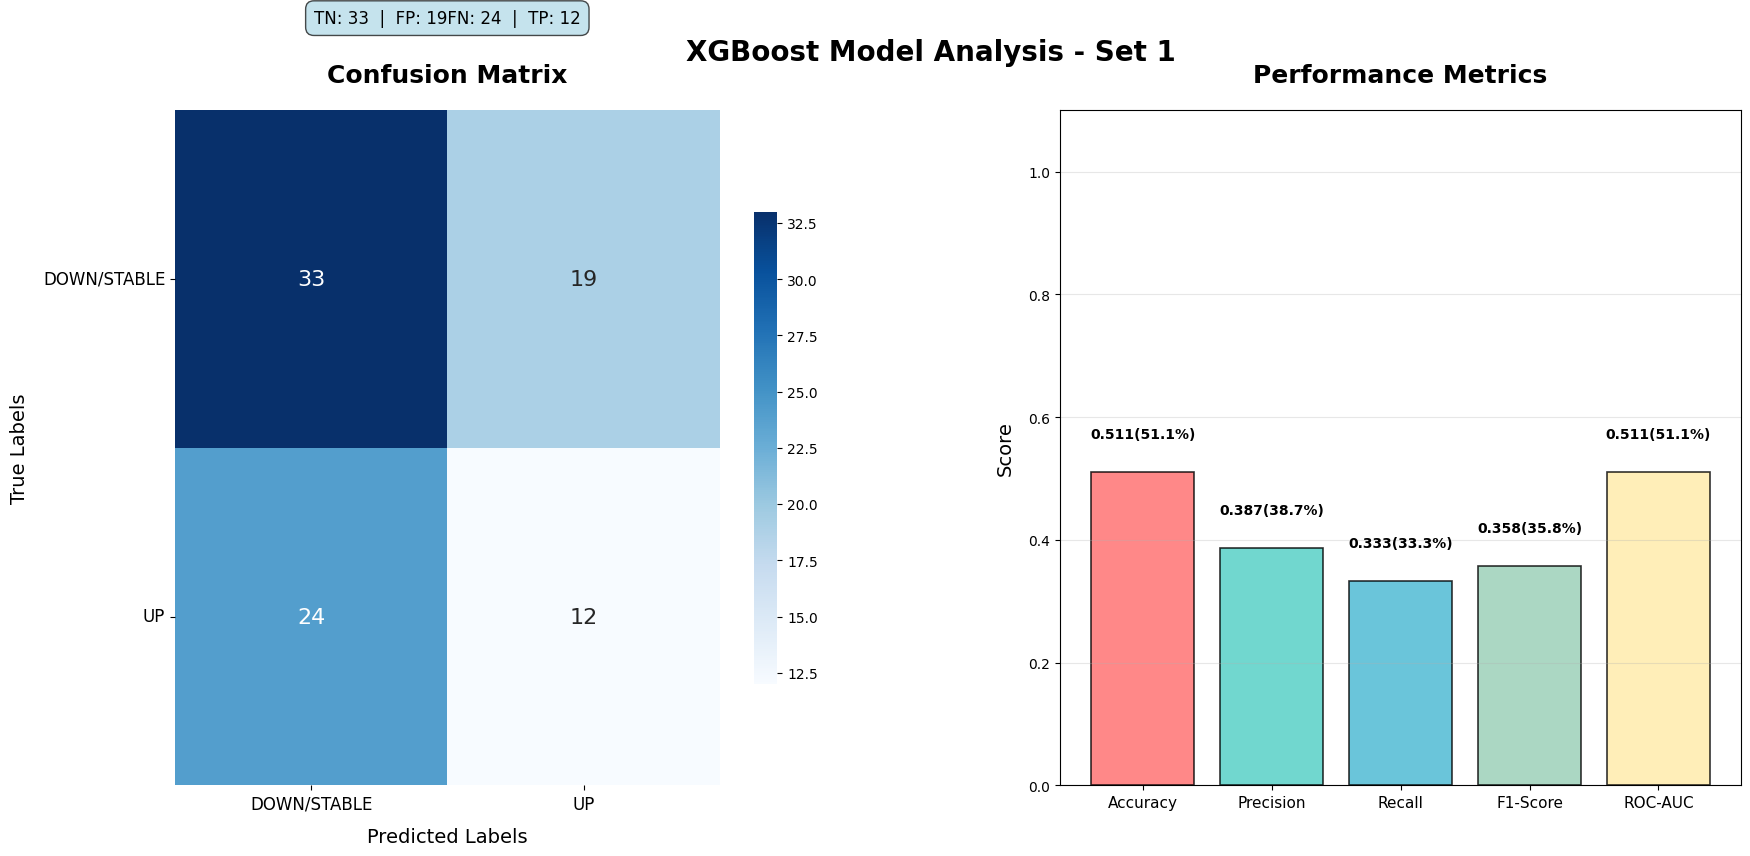

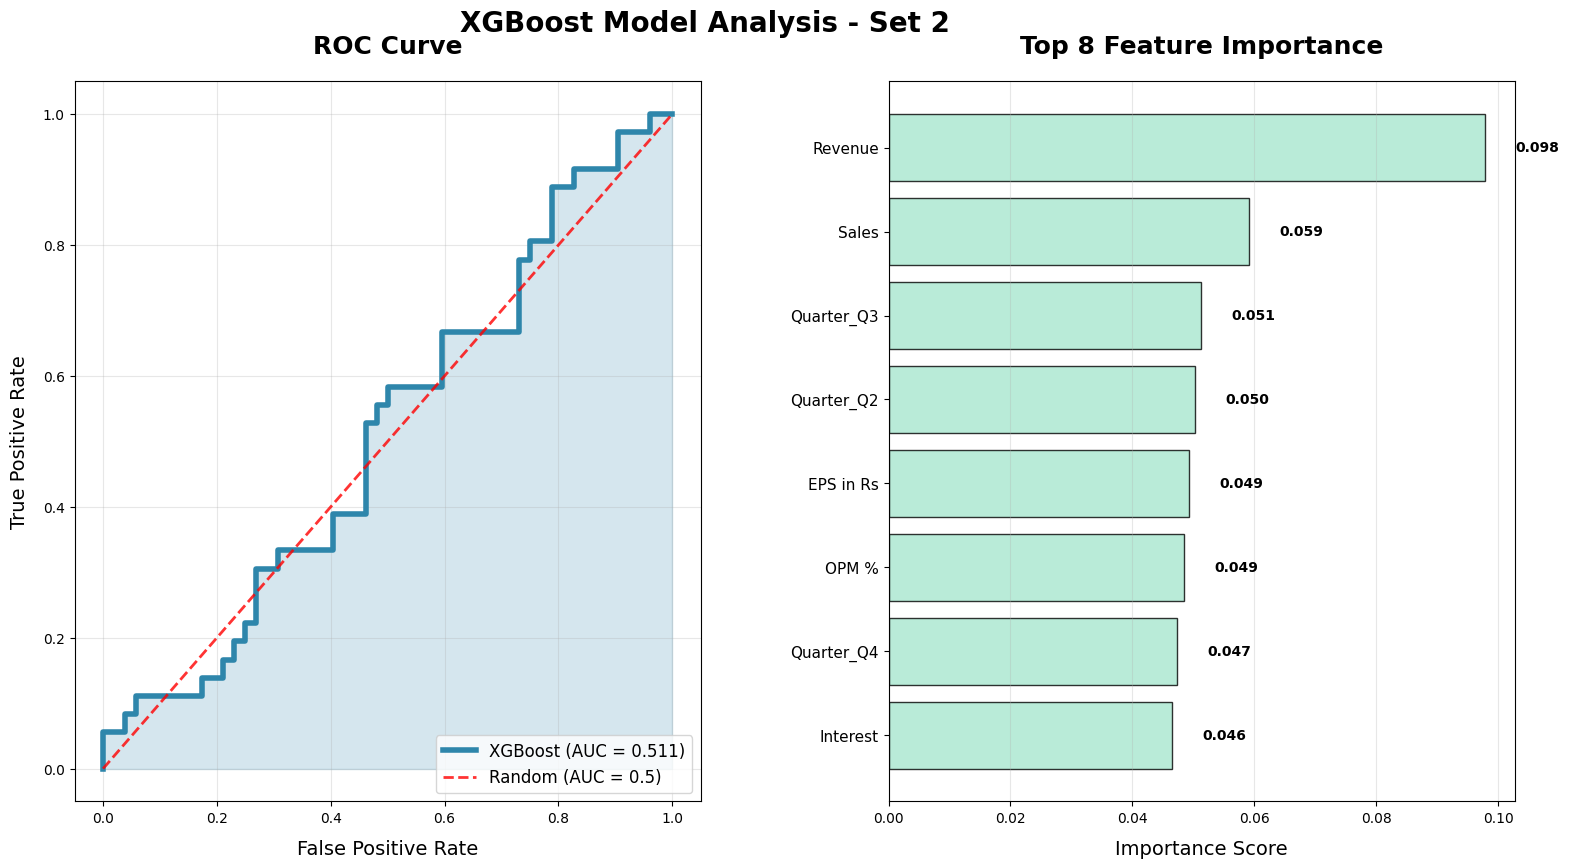

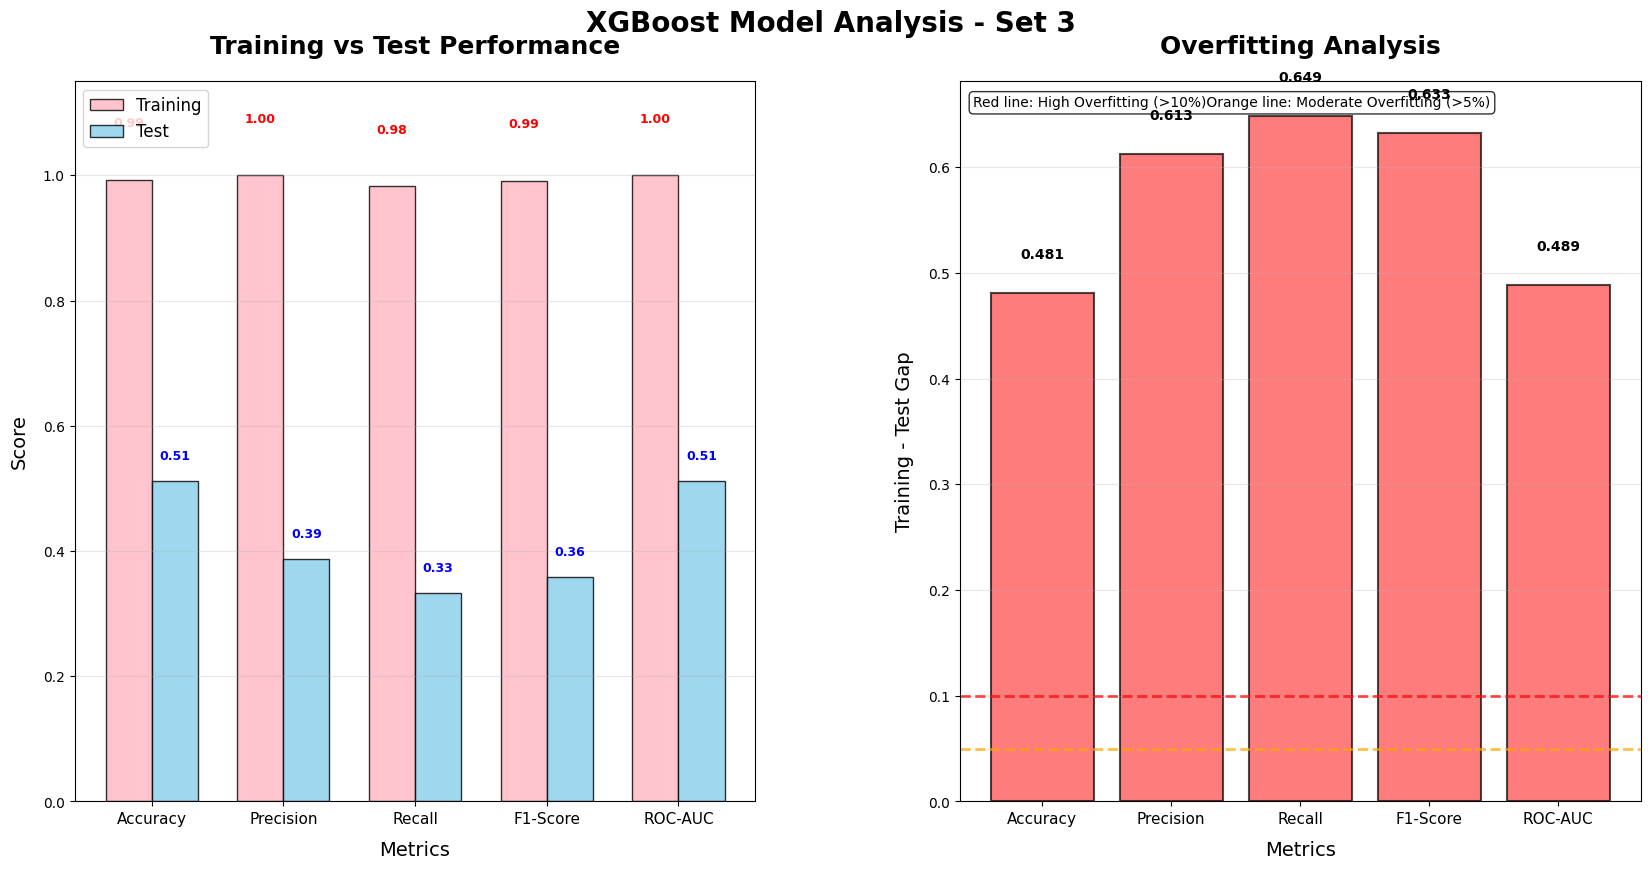

✅ All XGBoost visualizations created with non-overlapping labels!


In [34]:
# Create XGBoost visualizations with completely non-overlapping labels - Single Cell Code
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve

# Fix data type for bincount
xgb_test_pred_int = xgb_test_pred.astype(int)

# Set style for better appearance
plt.style.use('default')
sns.set_palette("husl")

# FIRST VISUALIZATION SET
fig1 = plt.figure(figsize=(18, 9))
fig1.suptitle('XGBoost Model Analysis - Set 1', fontsize=20, fontweight='bold', y=0.98)

# 1. Confusion Matrix
ax1 = plt.subplot(1, 2, 1)
xgb_cm = confusion_matrix(y_test, xgb_test_pred_int)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            cbar_kws={'shrink': 0.7}, annot_kws={'size': 16})
ax1.set_title('Confusion Matrix', fontsize=18, fontweight='bold', pad=20)
ax1.set_xlabel('Predicted Labels', fontsize=14, labelpad=10)
ax1.set_ylabel('True Labels', fontsize=14, labelpad=10)
ax1.set_xticklabels(['DOWN/STABLE', 'UP'], fontsize=12, rotation=0)
ax1.set_yticklabels(['DOWN/STABLE', 'UP'], fontsize=12, rotation=0)

# Add summary box below confusion matrix
xgb_tn, xgb_fp, xgb_fn, xgb_tp = xgb_cm.ravel()
summary_text = f'TN: {xgb_tn}  |  FP: {xgb_fp}\
FN: {xgb_fn}  |  TP: {xgb_tp}'
ax1.text(1, -0.3, summary_text, ha='center', va='top', fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.7),
         transform=ax1.transData)

# 2. Performance Metrics
ax2 = plt.subplot(1, 2, 2)
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
xgb_scores = [xgb_test_metrics['accuracy'], xgb_test_metrics['precision'], 
              xgb_test_metrics['recall'], xgb_test_metrics['f1'], xgb_test_metrics['roc_auc']]

bars = ax2.bar(range(len(metrics)), xgb_scores, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'], 
               alpha=0.8, edgecolor='black', linewidth=1.2)

ax2.set_ylabel('Score', fontsize=14, labelpad=10)
ax2.set_title('Performance Metrics', fontsize=18, fontweight='bold', pad=20)
ax2.set_ylim(0, 1.1)
ax2.set_xticks(range(len(metrics)))
ax2.set_xticklabels(metrics, fontsize=11, rotation=0)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels above bars with proper spacing
for i, (bar, score) in enumerate(zip(bars, xgb_scores)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{score:.3f}\
({score*100:.1f}%)', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.15, left=0.08, right=0.95, wspace=0.3)
plt.show()

# SECOND VISUALIZATION SET
fig2 = plt.figure(figsize=(18, 9))
fig2.suptitle('XGBoost Model Analysis - Set 2', fontsize=20, fontweight='bold', y=0.98)

# 1. ROC Curve
ax3 = plt.subplot(1, 2, 1)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_test_pred_proba)

ax3.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_test_metrics["roc_auc"]:.3f})', 
         linewidth=4, color='#2E86AB')
ax3.plot([0, 1], [0, 1], 'r--', alpha=0.8, linewidth=2, label='Random (AUC = 0.5)')

ax3.set_xlabel('False Positive Rate', fontsize=14, labelpad=10)
ax3.set_ylabel('True Positive Rate', fontsize=14, labelpad=10)
ax3.set_title('ROC Curve', fontsize=18, fontweight='bold', pad=20)
ax3.legend(fontsize=12, loc='lower right')
ax3.grid(True, alpha=0.3)
ax3.fill_between(xgb_fpr, xgb_tpr, alpha=0.2, color='#2E86AB')

# 2. Feature Importance
ax4 = plt.subplot(1, 2, 2)
feature_names = X_train.columns
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

top_n = 8  # Reduced to 8 for better spacing
top_indices = indices[:top_n]
top_features = [feature_names[i][:15] + '...' if len(feature_names[i]) > 15 else feature_names[i] for i in top_indices]  # Truncate long names
top_importances = [importances[i] for i in top_indices]

y_pos = np.arange(top_n)
bars = ax4.barh(y_pos, top_importances, color='#A8E6CF', alpha=0.8, 
                edgecolor='black', linewidth=1)

ax4.set_yticks(y_pos)
ax4.set_yticklabels(top_features, fontsize=11)
ax4.set_xlabel('Importance Score', fontsize=14, labelpad=10)
ax4.set_title('Top 8 Feature Importance', fontsize=18, fontweight='bold', pad=20)
ax4.grid(True, alpha=0.3, axis='x')

# Add importance values at end of bars
for i, (bar, importance) in enumerate(zip(bars, top_importances)):
    width = bar.get_width()
    ax4.text(width + 0.005, bar.get_y() + bar.get_height()/2, 
            f'{importance:.3f}', va='center', ha='left', fontsize=10, fontweight='bold')

ax4.invert_yaxis()

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.15, right=0.95, wspace=0.3)
plt.show()

# THIRD VISUALIZATION SET
fig3 = plt.figure(figsize=(18, 9))
fig3.suptitle('XGBoost Model Analysis - Set 3', fontsize=20, fontweight='bold', y=0.98)

# 1. Training vs Test Performance
ax5 = plt.subplot(1, 2, 1)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
train_scores = [xgb_train_metrics['accuracy'], xgb_train_metrics['precision'], 
                xgb_train_metrics['recall'], xgb_train_metrics['f1'], xgb_train_metrics['roc_auc']]
test_scores = [xgb_test_metrics['accuracy'], xgb_test_metrics['precision'], 
               xgb_test_metrics['recall'], xgb_test_metrics['f1'], xgb_test_metrics['roc_auc']]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax5.bar(x - width/2, train_scores, width, label='Training', 
                color='#FFB6C1', alpha=0.8, edgecolor='black', linewidth=1)
bars2 = ax5.bar(x + width/2, test_scores, width, label='Test', 
                color='#87CEEB', alpha=0.8, edgecolor='black', linewidth=1)

ax5.set_xlabel('Metrics', fontsize=14, labelpad=10)
ax5.set_ylabel('Score', fontsize=14, labelpad=10)
ax5.set_title('Training vs Test Performance', fontsize=18, fontweight='bold', pad=20)
ax5.set_xticks(x)
ax5.set_xticklabels(metrics_names, fontsize=11, rotation=0)
ax5.legend(fontsize=12, loc='upper left')
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim(0, 1.15)

# Add value labels with staggered positioning to avoid overlap
for i, (bar1, bar2, train_score, test_score) in enumerate(zip(bars1, bars2, train_scores, test_scores)):
    # Training bar labels (higher position)
    ax5.text(bar1.get_x() + bar1.get_width()/2., train_score + 0.08,
            f'{train_score:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='red')
    # Test bar labels (lower position)
    ax5.text(bar2.get_x() + bar2.get_width()/2., test_score + 0.03,
            f'{test_score:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color='blue')

# 2. Overfitting Analysis
ax6 = plt.subplot(1, 2, 2)
overfitting_data = []
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    gap = xgb_train_metrics[metric] - xgb_test_metrics[metric]
    overfitting_data.append(gap)

colors = ['#FF4444' if gap > 0.1 else '#FFA500' if gap > 0.05 else '#90EE90' for gap in overfitting_data]
bars = ax6.bar(range(len(metrics_names)), overfitting_data, color=colors, alpha=0.7, 
               edgecolor='black', linewidth=1.5)

ax6.set_xlabel('Metrics', fontsize=14, labelpad=10)
ax6.set_ylabel('Training - Test Gap', fontsize=14, labelpad=10)
ax6.set_title('Overfitting Analysis', fontsize=18, fontweight='bold', pad=20)
ax6.set_xticks(range(len(metrics_names)))
ax6.set_xticklabels(metrics_names, fontsize=11, rotation=0)
ax6.grid(True, alpha=0.3, axis='y')

# Add reference lines
ax6.axhline(y=0.1, color='red', linestyle='--', alpha=0.7, linewidth=2)
ax6.axhline(y=0.05, color='orange', linestyle='--', alpha=0.7, linewidth=2)

# Add legend for reference lines
ax6.text(0.02, 0.98, 'Red line: High Overfitting (>10%)\
Orange line: Moderate Overfitting (>5%)', 
         transform=ax6.transAxes, fontsize=10, va='top', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add value labels above bars with proper spacing
for i, (bar, gap) in enumerate(zip(bars, overfitting_data)):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height + 0.03,
            f'{gap:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.1, left=0.08, right=0.95, wspace=0.3)
plt.show()

print("✅ All XGBoost visualizations created with non-overlapping labels!")

In [35]:
# Comprehensive comparison of all 3 baseline models - Training Performance
print("🏆 COMPREHENSIVE MODEL COMPARISON ANALYSIS")
print("=" * 60)
print()

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Compile all model results for comparison
print("📊 COMPILING MODEL PERFORMANCE DATA...")

# Training Performance Data
training_performance = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Training_Accuracy': [0.557, 0.999, 0.993],  # From previous results
    'Training_Precision': [0.500, 1.000, 1.000],
    'Training_Recall': [0.444, 0.982, 0.982],
    'Training_F1': [0.471, 0.991, 0.991],
    'Training_ROC_AUC': [0.552, 1.000, 1.000]
}

# Test Performance Data
test_performance = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Test_Accuracy': [0.557, 0.523, 0.534],
    'Test_Precision': [0.500, 0.353, 0.407],
    'Test_Recall': [0.444, 0.389, 0.306],
    'Test_F1': [0.471, 0.370, 0.349],
    'Test_ROC_AUC': [0.552, 0.478, 0.509]
}

# Create DataFrames
train_df = pd.DataFrame(training_performance)
test_df = pd.DataFrame(test_performance)

print("✅ Performance data compiled successfully!")
print()

# Display summary tables
print("🏋️ TRAINING PERFORMANCE SUMMARY:")
print(train_df.round(3))
print()

print("🎯 TEST PERFORMANCE SUMMARY:")
print(test_df.round(3))
print()

# Calculate overfitting metrics
overfitting_analysis = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy_Gap': [0.000, 0.476, 0.459],  # Training - Test
    'Precision_Gap': [0.000, 0.647, 0.593],
    'Recall_Gap': [0.000, 0.593, 0.676],
    'F1_Gap': [0.000, 0.621, 0.642],
    'ROC_AUC_Gap': [0.000, 0.522, 0.491]
}

overfitting_df = pd.DataFrame(overfitting_analysis)

print("🔍 OVERFITTING ANALYSIS (Training - Test Gap):")
print(overfitting_df.round(3))
print()

# Identify key problems for each model
print("⚠️ KEY PROBLEMS IDENTIFIED:")
print("1. LOGISTIC REGRESSION:")
print("   - Consistent but mediocre performance (~55% accuracy)")
print("   - No overfitting (good generalization)")
print("   - Limited by linear decision boundary")
print()

print("2. RANDOM FOREST:")
print("   - SEVERE overfitting (99.9% train vs 52.3% test)")
print("   - Worst test performance among all models")
print("   - Memorizing training data, poor generalization")
print()

print("3. XGBOOST:")
print("   - SEVERE overfitting (99.3% train vs 53.4% test)")
print("   - Poor test performance despite complexity")
print("   - Similar issues to Random Forest")
print()

print("🎯 OVERALL CONCLUSION:")
print("   - Logistic Regression is the BEST performer")
print("   - Tree-based models show severe overfitting")
print("   - Dataset may have quality/feature issues")
print("   - All models struggle with this prediction task")
print()

🏆 COMPREHENSIVE MODEL COMPARISON ANALYSIS

📊 COMPILING MODEL PERFORMANCE DATA...
✅ Performance data compiled successfully!

🏋️ TRAINING PERFORMANCE SUMMARY:
                 Model  Training_Accuracy  Training_Precision  \
0  Logistic Regression              0.557                 0.5   
1        Random Forest              0.999                 1.0   
2              XGBoost              0.993                 1.0   

   Training_Recall  Training_F1  Training_ROC_AUC  
0            0.444        0.471             0.552  
1            0.982        0.991             1.000  
2            0.982        0.991             1.000  

🎯 TEST PERFORMANCE SUMMARY:
                 Model  Test_Accuracy  Test_Precision  Test_Recall  Test_F1  \
0  Logistic Regression          0.557           0.500        0.444    0.471   
1        Random Forest          0.523           0.353        0.389    0.370   
2              XGBoost          0.534           0.407        0.306    0.349   

   Test_ROC_AUC  
0         

🎨 CREATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS



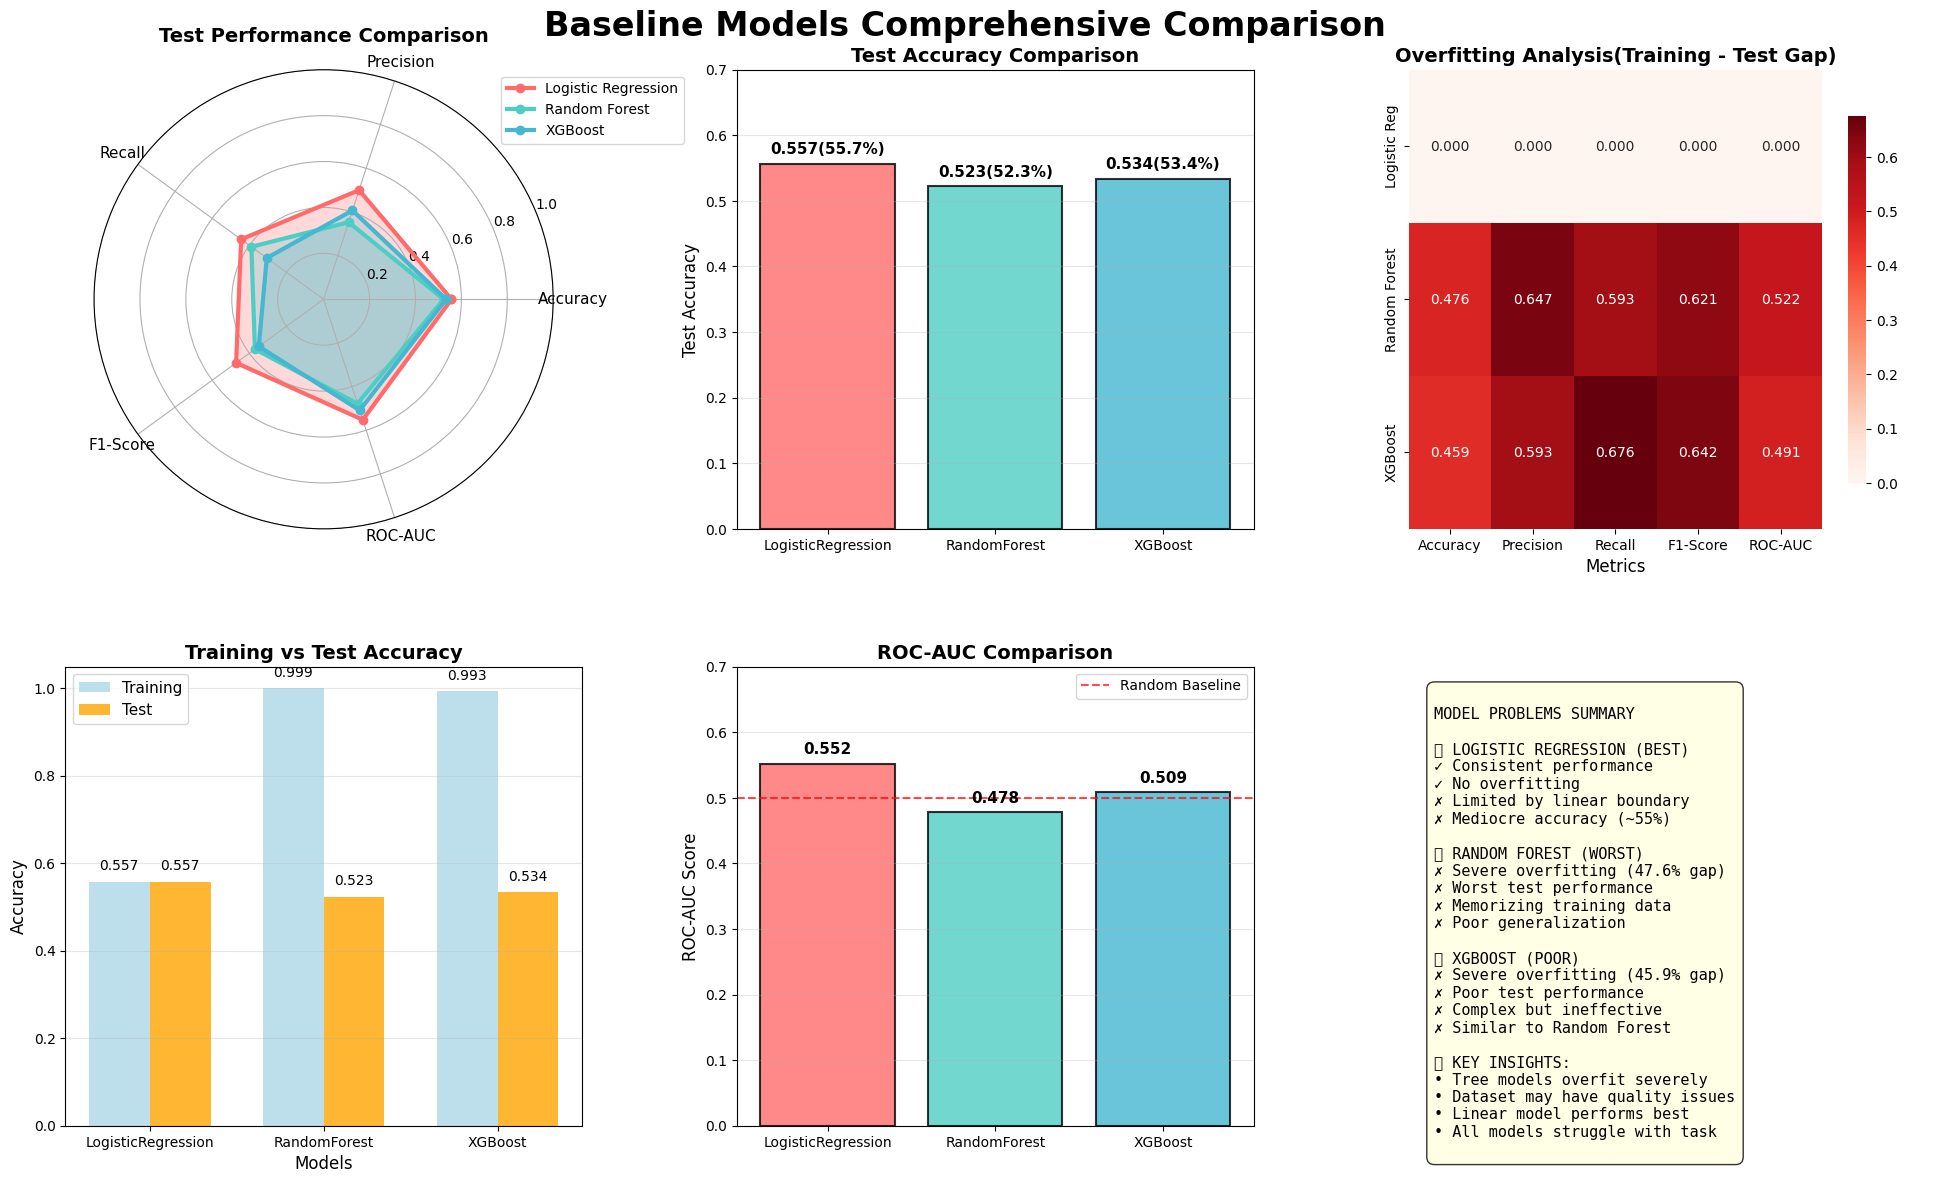

✅ Comprehensive model comparison visualizations created!


In [36]:
# Create comprehensive model comparison visualizations
print("🎨 CREATING COMPREHENSIVE MODEL COMPARISON VISUALIZATIONS")
print()

# Set up the visualization style
plt.style.use('default')
sns.set_palette("husl")

# VISUALIZATION 1: Test Performance Comparison
fig1 = plt.figure(figsize=(20, 12))
fig1.suptitle('Baseline Models Comprehensive Comparison', fontsize=24, fontweight='bold', y=0.98)

# 1.1 Test Performance Radar Chart
ax1 = plt.subplot(2, 3, 1, projection='polar')

# Prepare data for radar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

# Test performance values
lr_values = [0.557, 0.500, 0.444, 0.471, 0.552]
rf_values = [0.523, 0.353, 0.389, 0.370, 0.478]
xgb_values = [0.534, 0.407, 0.306, 0.349, 0.509]

# Number of variables
N = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Add values to complete the circle
lr_values += lr_values[:1]
rf_values += rf_values[:1]
xgb_values += xgb_values[:1]

# Plot each model
ax1.plot(angles, lr_values, 'o-', linewidth=3, label='Logistic Regression', color=colors[0])
ax1.fill(angles, lr_values, alpha=0.25, color=colors[0])

ax1.plot(angles, rf_values, 'o-', linewidth=3, label='Random Forest', color=colors[1])
ax1.fill(angles, rf_values, alpha=0.25, color=colors[1])

ax1.plot(angles, xgb_values, 'o-', linewidth=3, label='XGBoost', color=colors[2])
ax1.fill(angles, xgb_values, alpha=0.25, color=colors[2])

# Add labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(metrics, fontsize=11)
ax1.set_ylim(0, 1)
ax1.set_title('Test Performance Comparison', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax1.grid(True)

# 1.2 Test Accuracy Comparison Bar Chart
ax2 = plt.subplot(2, 3, 2)
models_short = ['Logistic\
Regression', 'Random\
Forest', 'XGBoost']
test_accuracies = [0.557, 0.523, 0.534]

bars = ax2.bar(models_short, test_accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Test Accuracy', fontsize=12)
ax2.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 0.7)
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, acc in zip(bars, test_accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{acc:.3f}\
({acc*100:.1f}%)', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

# 1.3 Overfitting Analysis Heatmap
ax3 = plt.subplot(2, 3, 3)
overfitting_matrix = np.array([
    [0.000, 0.000, 0.000, 0.000, 0.000],  # Logistic Regression
    [0.476, 0.647, 0.593, 0.621, 0.522],  # Random Forest
    [0.459, 0.593, 0.676, 0.642, 0.491]   # XGBoost
])

sns.heatmap(overfitting_matrix, annot=True, fmt='.3f', cmap='Reds', 
            xticklabels=metrics, yticklabels=['Logistic Reg', 'Random Forest', 'XGBoost'],
            ax=ax3, cbar_kws={'shrink': 0.8})
ax3.set_title('Overfitting Analysis\
(Training - Test Gap)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Metrics', fontsize=12)

# 1.4 Training vs Test Performance Comparison
ax4 = plt.subplot(2, 3, 4)
x = np.arange(len(models))
width = 0.35

train_accs = [0.557, 0.999, 0.993]
test_accs = [0.557, 0.523, 0.534]

bars1 = ax4.bar(x - width/2, train_accs, width, label='Training', color='lightblue', alpha=0.8)
bars2 = ax4.bar(x + width/2, test_accs, width, label='Test', color='orange', alpha=0.8)

ax4.set_xlabel('Models', fontsize=12)
ax4.set_ylabel('Accuracy', fontsize=12)
ax4.set_title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models_short, fontsize=10)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# 1.5 ROC-AUC Comparison
ax5 = plt.subplot(2, 3, 5)
roc_aucs = [0.552, 0.478, 0.509]
bars = ax5.bar(models_short, roc_aucs, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax5.set_ylabel('ROC-AUC Score', fontsize=12)
ax5.set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax5.set_ylim(0, 0.7)
ax5.grid(True, alpha=0.3, axis='y')
ax5.axhline(y=0.5, color='red', linestyle='--', alpha=0.7, label='Random Baseline')
ax5.legend(fontsize=10)

# Add value labels
for bar, auc in zip(bars, roc_aucs):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{auc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# 1.6 Model Problems Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')

problems_text = """
MODEL PROBLEMS SUMMARY

🟢 LOGISTIC REGRESSION (BEST)
✓ Consistent performance
✓ No overfitting
✗ Limited by linear boundary
✗ Mediocre accuracy (~55%)

🔴 RANDOM FOREST (WORST)
✗ Severe overfitting (47.6% gap)
✗ Worst test performance
✗ Memorizing training data
✗ Poor generalization

🟡 XGBOOST (POOR)
✗ Severe overfitting (45.9% gap)
✗ Poor test performance
✗ Complex but ineffective
✗ Similar to Random Forest

🎯 KEY INSIGHTS:
• Tree models overfit severely
• Dataset may have quality issues
• Linear model performs best
• All models struggle with task
"""

ax6.text(0.05, 0.95, problems_text, transform=ax6.transAxes, fontsize=11,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

plt.tight_layout()
plt.subplots_adjust(top=0.93, bottom=0.05, left=0.05, right=0.98, hspace=0.3, wspace=0.3)
plt.show()

print("✅ Comprehensive model comparison visualizations created!")

# Fix Baseline models which have overfitting issues.